In [1]:
!git clone https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git
%cd Natural_MDM2_Inhibitor_Discovery_using_ML

Cloning into 'Natural_MDM2_Inhibitor_Discovery_using_ML'...
remote: Enumerating objects: 1397, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 1397 (delta 127), reused 79 (delta 62), pack-reused 1200 (from 2)
Receiving objects: 100% (1397/1397), 99.50 MiB | 18.46 MiB/s, done.
Resolving deltas: 100% (803/803), done.
/content/Natural_MDM2_Inhibitor_Discovery_using_ML


In [2]:
# Updated 2026-09: pin compatible versions; seyonec/ChemBERTa-zinc-base-v1 still live (6779126 downloads) but author recommends DeepChem/ChemBERTa-10M-MTR — kept for reproducibility
# See: https://huggingface.co/seyonec/ChemBERTa-zinc-base-v1/discussions/1 + https://github.com/seyonechithrananda/bert-loves-chemistry/issues/7
!pip install -q "torch>=2.2" "torch-geometric>=2.5" "rdkit>=2023.09" "transformers>=4.40" "tqdm" "gdown" "scikit-learn" "seaborn"
# Optional newer ChemBERTa (uncomment to switch):
# from transformers import AutoTokenizer, AutoModel  # use "DeepChem/ChemBERTa-10M-MTR" instead of "seyonec/ChemBERTa-zinc-base-v1"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 17.2 MB/s eta 0:00:0000:0100:01m


# Part 15: Small-Data Deep Learning for MDM2 — Regression Delta-ML

Trains three **small-data-safe** deep-learning regressors on the 645 MDM2 compounds.
With n=645, big GNNs overfit (Part 12 AttentiveFP ~350k params: AUC 0.924 <
Part 13 Hybrid ~60k params: 0.956 < RF: 0.960), so every model here stays under
~50k trainable params and follows the same protocol as Parts 9/10/12/13:
80/20 split (seed=57), 100 epochs, 10x Y-randomization, 5-fold CV.

**Fix for COCONUT saturation (avg_prob>0.5 → 62k hits, top10=1.0):** switch from binary classification
(`num_classes=2`, `CrossEntropy`, `softmax`) to **continuous regression on pIC50** with optional
**Delta-ML** (`Δ = pIC50 - cheap baseline`). Continuous outputs do not collapse via sigmoid.
Ensemble mean + variance ranking replaces probability thresholding.

**References:**
1. D-MPNN — Yang et al., "Analyzing Learned Molecular Representations for Property Prediction," *J. Chem. Inf. Model.* 2019 (Chemprop).
2. GINE — Hu et al., "Strategies for Pre-training Graph Neural Networks," *ICLR* 2020.
3. ChemBERTa — Chithrananda et al., "ChemBERTa: Large-Scale Self-Supervised Pretraining for Molecular Property Prediction," *arXiv:2010.09885* 2020.

**Pipeline:** SMILES → RDKit graphs (78-dim atoms + 6-dim bonds) →
SMILES-enumeration augmentation (train-only, x4) → D-MPNN-small / GINE-small / frozen-ChemBERTa + MLP (out_dim=1) →
Ridge baseline on RDKit descriptors (MW, logP, TPSA, HBA/HBD, RotBonds) for delta → StandardScaler on train → MSE/Huber


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_add_pool
from torch_geometric.utils import scatter
from torch.utils.data import TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.utils import shuffle
from rdkit import Chem
from rdkit.Chem import Descriptors
import warnings
warnings.filterwarnings('ignore')

try:
    from transformers import AutoTokenizer, AutoModel
    HAVE_HF = True
except Exception as e:
    HAVE_HF = False
    print(f"transformers not available ({e}) — ChemBERTa section will be skipped.")

RANDOM_SEED = 57
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"ChemBERTa available: {HAVE_HF}")

# --- Task / Delta flags ---
TASK = "regression"   # regression only (classification branch removed)
USE_DELTA = True      # if True, model learns delta = pIC50 - baseline_pred
REGRESSION_LOSS = "mse"  # mse | huber
TARGET_COL = "pIC50"


Device: cuda
ChemBERTa available: True


## 1. Define Small-Data Architectures

In [4]:
# === Feature / filtering flags — all OFF by default (flag-only) ===
# GRAPH-FIRST: DL works on RDKit graphs (78-dim atoms + 6-dim bonds) directly.
# Fingerprints are flag-only supplements — OFF unless you explicitly set True.
# No fingerprint is concatenated unless flag True — keeps graph signal pure.
USE_MACCS = False
MACCS_DIM = 167
MACCS_PROJ_DIM = 32
USE_MORGAN = False
MORGAN_DIM = 1024
MORGAN_RADIUS = 2

# --- data filtering flags (OFF by default unless noted) ---
FILTER_DUP_SMILES = True       # True = drop duplicate canonical SMILES (keep max pIC50) — reduces leakage
FILTER_PIC50_OUTLIER = False   # IQR clip on pIC50 (False = keep all 645)
FILTER_INVALID_PIC50 = True    # always drop NaN pIC50 (required for regression)
APPLICABILITY_DOMAIN_FILTER = False  # screening-only AD filter (ensemble variance / Tanimoto) — annotate only unless True
STRICT_MEDCHEM = False         # screening-only: if True hard-require PAINS+Brenk+Ro5; else rank only (filter accuracy mode)

# --- regularization / training flags (graph-first overfit fixes) ---
RIDGE_ALPHA = 1.0
WEIGHT_DECAY = 1e-4             # L2 for Adam — mitigates 23-49k params on 516 samples
USE_EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 15        # epochs without R2 improvement before restore best
DROPOUT_DMPNN = 0.3             # was 0.2 — higher for small data
DROPOUT_GINE = 0.4              # was 0.3
DROPOUT_CHEMBERTA = 0.4         # was 0.3
AUGMENT_N = 2                   # was 4 — 516*2=1032 graphs, less duplicate-scaffold inflation


def maccs_from_mol(mol):
    import numpy as np
    from rdkit import DataStructs
    from rdkit.Chem import MACCSkeys
    try:
        bv = MACCSkeys.GenMACCSKeys(mol)
        arr = np.zeros((MACCS_DIM,), dtype=np.float32)
        DataStructs.ConvertToNumpyArray(bv, arr)
        return arr
    except Exception:
        import numpy as np
        return np.zeros((MACCS_DIM,), dtype=np.float32)


def maccs_from_smiles(smi):
    from rdkit import Chem
    import numpy as np
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return np.zeros((MACCS_DIM,), dtype=np.float32)
        return maccs_from_mol(mol)
    except Exception:
        return np.zeros((MACCS_DIM,), dtype=np.float32)


def morgan_from_smiles(smi, radius=MORGAN_RADIUS, n_bits=MORGAN_DIM):
    """Flag-only Morgan fingerprint (OFF unless USE_MORGAN=True)."""
    from rdkit import Chem
    from rdkit.Chem import rdFingerprintGenerator
    import numpy as np
    try:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            return np.zeros((n_bits,), dtype=np.float32)
        gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
        fp = gen.GetFingerprint(mol)
        arr = np.zeros((n_bits,), dtype=np.float32)
        from rdkit import DataStructs
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except Exception:
        import numpy as np
        return np.zeros((n_bits,), dtype=np.float32)


## FAST screening mode (disabled to match working notebook) — set `FAST_MODE=True` only if `*.pth` exist
This cell was `FAST_MODE=True` in fast notebook causing `NameError: dmpnn_losses` / `HAVE_CB` when checkpoints missing. Now `False` as in `colabtestregressiom.ipynb`.


In [5]:
FAST_MODE = False  # fixed: was True causing load-skip deadlock (no .pth -> undefined vars). Set True only if checkpoints exist.
APPLICABILITY_DOMAIN_FILTER = False  # screening-only AD filter — as in full notebook (wired in ensemble/save)
PRED_CAP = 10.0  # realistic pIC50 cap — enforced via np.clip in screening (was defined but never applied)
print(f'FAST_MODE={FAST_MODE} | APPLICABILITY_DOMAIN_FILTER={APPLICABILITY_DOMAIN_FILTER} | cap={PRED_CAP} | WEIGHT_DECAY={WEIGHT_DECAY} | EARLY_STOP={USE_EARLY_STOPPING}:{EARLY_STOP_PATIENCE} | AUGMENT_N={AUGMENT_N} | DUP_FILTER={FILTER_DUP_SMILES} | DROPOUT {DROPOUT_DMPNN}/{DROPOUT_GINE}/{DROPOUT_CHEMBERTA} | FINGERPRINT MACCS={USE_MACCS} MORGAN={USE_MORGAN} (graph-first default OFF)')


FAST_MODE=False | APPLICABILITY_DOMAIN_FILTER=False | cap=10.0 | WEIGHT_DECAY=0.0001 | EARLY_STOP=True:15 | AUGMENT_N=2 | DUP_FILTER=True | DROPOUT 0.3/0.4/0.4 | FINGERPRINT MACCS=False MORGAN=False (graph-first default OFF)


In [6]:
class DirectedMPNN(nn.Module):
    """Directed message-passing network after Yang et al. 2019 (Chemprop).

    Messages live on directed bonds; each update excludes the reverse edge
    (no tottering), with a skip connection from the initial edge state.
    hidden=64, depth=2 -> ~23k params (small-data-safe).
    Regression head: out_dim=1 (pIC50 or delta)."""

    def __init__(self, num_node_features=78, num_edge_features=6, hidden_dim=64,
                 depth=2, dropout=0.2, out_dim=1,
                 use_maccs=False, maccs_dim=167, maccs_proj_dim=32,
                 use_morgan=False, morgan_dim=1024):
        super().__init__()
        self.depth = depth
        self.dropout = dropout
        self.edge_init = nn.Linear(num_node_features + num_edge_features, hidden_dim)
        self.edge_update = nn.Linear(hidden_dim, hidden_dim)
        self.atom_update = nn.Linear(num_node_features + hidden_dim, hidden_dim)
        # MACCS/Morgan fusion (off by default -> identical to original model)
        self.use_maccs = use_maccs
        self.use_morgan = use_morgan
        extra_dim = 0
        if use_maccs:
            self.maccs_proj = nn.Sequential(nn.Linear(maccs_dim, maccs_proj_dim), nn.ReLU())
            extra_dim += maccs_proj_dim
        if use_morgan:
            self.morgan_proj = nn.Sequential(nn.Linear(morgan_dim, 32), nn.ReLU())
            extra_dim += 32
        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim + extra_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x, edge_index, edge_attr, batch, maccs=None, morgan=None):
        src, dst = edge_index
        n_nodes = x.size(0)
        n_edges = src.size(0)
        key = src * n_nodes + dst
        rkey = dst * n_nodes + src
        order = torch.argsort(key)
        pos = torch.searchsorted(key[order], rkey)
        rev = order[pos.clamp(max=n_edges - 1)]

        h0 = F.relu(self.edge_init(torch.cat([x[src], edge_attr], dim=1)))
        h = h0
        for _ in range(self.depth):
            incoming = scatter(h, dst, dim=0, dim_size=n_nodes, reduce='sum')
            m = incoming[src] - h[rev]
            h = F.relu(h0 + F.dropout(self.edge_update(m), p=self.dropout, training=self.training))
        atom_in = scatter(h, dst, dim=0, dim_size=n_nodes, reduce='sum')
        a = F.relu(self.atom_update(torch.cat([x, atom_in], dim=1)))
        g = global_add_pool(a, batch)
        extras = []
        if self.use_maccs:
            if maccs is not None:
                extras.append(self.maccs_proj(maccs.to(dtype=g.dtype, device=g.device)))
            else:
                extras.append(torch.zeros((g.size(0), MACCS_PROJ_DIM), device=g.device, dtype=g.dtype))
        if self.use_morgan:
            if morgan is not None:
                extras.append(self.morgan_proj(morgan.to(dtype=g.dtype, device=g.device)))
            else:
                extras.append(torch.zeros((g.size(0), 32), device=g.device, dtype=g.dtype))
        if extras:
            g = torch.cat([g] + extras, dim=1)
        return self.ffn(g).squeeze(-1)  # [B] for regression


In [7]:
class GINELayer(nn.Module):
    """Single GIN-with-edge-features layer after Hu et al. 2020.

    h_v = MLP_node((1 + eps) * h_v + sum_{u in N(v)} (h_u + MLP_edge(e_uv)))."""

    def __init__(self, in_dim, hidden_dim=64, edge_dim=6):
        super().__init__()
        self.proj = nn.Linear(in_dim, hidden_dim) if in_dim != hidden_dim else nn.Identity()
        self.edge_mlp = nn.Sequential(nn.Linear(edge_dim, hidden_dim), nn.ReLU())
        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.eps = nn.Parameter(torch.zeros(1))

    def forward(self, x, edge_index, edge_attr):
        src, dst = edge_index
        h = self.proj(x)
        msg = scatter(h[src] + self.edge_mlp(edge_attr), dst,
                      dim=0, dim_size=x.size(0), reduce='sum')
        return self.node_mlp((1.0 + self.eps) * h + msg)


class GINESmall(nn.Module):
    """3-layer GINE, hidden=64 -> ~40k params (small-data-safe). Regression head out_dim=1."""

    def __init__(self, num_node_features=78, num_edge_features=6, hidden_dim=64,
                 num_layers=3, dropout=0.3, out_dim=1,
                 use_maccs=False, maccs_dim=167, maccs_proj_dim=32,
                 use_morgan=False, morgan_dim=1024):
        super().__init__()
        self.layers = nn.ModuleList([
            GINELayer(num_node_features if i == 0 else hidden_dim, hidden_dim, num_edge_features)
            for i in range(num_layers)
        ])
        self.dropout = dropout
        self.use_maccs = use_maccs
        self.use_morgan = use_morgan
        extra_dim = 0
        if use_maccs:
            self.maccs_proj = nn.Sequential(nn.Linear(maccs_dim, maccs_proj_dim), nn.ReLU())
            extra_dim += maccs_proj_dim
        if use_morgan:
            self.morgan_proj = nn.Sequential(nn.Linear(morgan_dim, 32), nn.ReLU())
            extra_dim += 32
        self.head = nn.Sequential(
            nn.Linear(hidden_dim + extra_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, out_dim)
        )

    def forward(self, x, edge_index, edge_attr, batch, maccs=None, morgan=None):
        for layer in self.layers:
            x = F.relu(layer(x, edge_index, edge_attr))
            x = F.dropout(x, p=self.dropout, training=self.training)
        g = global_add_pool(x, batch)
        extras = []
        if self.use_maccs:
            extras.append(self.maccs_proj(maccs.to(dtype=g.dtype, device=g.device)) if maccs is not None else torch.zeros((g.size(0), MACCS_PROJ_DIM), device=g.device, dtype=g.dtype))
        if self.use_morgan:
            extras.append(self.morgan_proj(morgan.to(dtype=g.dtype, device=g.device)) if morgan is not None else torch.zeros((g.size(0), 32), device=g.device, dtype=g.dtype))
        if extras:
            g = torch.cat([g] + extras, dim=1)
        return self.head(g).squeeze(-1)


In [8]:
class ChemBERTaMLP(nn.Module):
    """Trainable head on FROZEN ChemBERTa embeddings (Chithrananda et al. 2020).

    The language model (pretrained on ~77M SMILES from ZINC) is never updated;
    only this 768->64->1 head trains (~49k params), so 645 compounds suffice.
    Regression output: single pIC50 / delta value."""

    def __init__(self, in_dim=768, hidden_dim=64, dropout=0.3, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, emb):
        return self.net(emb).squeeze(-1)


def chemberta_embed(smiles_list, tok, lm, batch_size=64):
    """Mean-pooled last-hidden-state embeddings (frozen, no grad)."""
    lm.eval()
    embs = []
    with torch.no_grad():
        for i in range(0, len(smiles_list), batch_size):
            enc = tok(smiles_list[i:i + batch_size], padding=True, truncation=True,
                      max_length=512, return_tensors='pt')
            enc = {k: v.to(device) for k, v in enc.items()}
            h = lm(**enc).last_hidden_state
            mask = enc['attention_mask'].unsqueeze(-1)
            embs.append(((h * mask).sum(1) / mask.sum(1).clamp(min=1)).cpu())
    return torch.cat(embs)


## 2. Load Data + Featurize

In [9]:
# --- Load MDM2 data for REGRESSION (robust to cwd: colab vs local) ---
def _try_read(cands):
    for f in cands:
        try:
            return pd.read_csv(f)
        except Exception:
            pass
    return None

df = _try_read([
    'Part_2/ro5_properties_filtered.csv',
    'Part_15/ro5_properties_filtered.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_15/ro5_properties_filtered.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_3/ro5_properties_filtered.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_15/ro5_properties_filtered.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_2/ro5_properties_filtered.csv',
    'ro5_properties_filtered.csv',
    '../Part_15/ro5_properties_filtered.csv',
    '../../Part_15/ro5_properties_filtered.csv'
])
if df is None:
    raise FileNotFoundError("ro5_properties_filtered.csv not found in any candidate path")
# ensure pIC50 present
if 'pIC50' not in df.columns:
    alt = _try_read(['Part_15/ro5_properties_filtered.csv','Natural_MDM2_Inhibitor_Discovery_using_ML/Part_15/ro5_properties_filtered.csv','Part_2/ro5_properties_filtered.csv'])
    if alt is not None and 'pIC50' in alt.columns:
        df = alt

print(f"Raw rows: {len(df)} | cols: {list(df.columns)[:8]}")

# --- filtering (flags OFF by default) ---
if FILTER_INVALID_PIC50:
    before = len(df)
    df = df[pd.notna(df[TARGET_COL])].copy()
    print(f"Invalid pIC50 dropped: {before-len(df)}")

if FILTER_DUP_SMILES and 'canonical_smiles' in df.columns:
    before=len(df)
    df = df.sort_values(TARGET_COL, ascending=False).drop_duplicates('canonical_smiles', keep='first')
    print(f"Dup SMILES removed: {before-len(df)} -> {len(df)}")

if FILTER_PIC50_OUTLIER:
    q1, q3 = df[TARGET_COL].quantile([0.25, 0.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    before=len(df)
    df = df[(df[TARGET_COL]>=lo) & (df[TARGET_COL]<=hi)].copy()
    print(f"IQR outlier filter [{lo:.2f},{hi:.2f}] removed {before-len(df)}")

# --- RDKit descriptors for cheap baseline (Ridge) ---
def rdkit_desc(smi):
    try:
        mol=Chem.MolFromSmiles(str(smi))
        if mol is None:
            return [0]*6
        return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
                Descriptors.NumHAcceptors(mol), Descriptors.NumHDonors(mol), Descriptors.NumRotatableBonds(mol)]
    except Exception:
        return [0]*6

desc_mat = np.array([rdkit_desc(s) for s in df['canonical_smiles']], dtype=float)
print(f"Descriptors: {desc_mat.shape} | pIC50 range [{df[TARGET_COL].min():.2f}, {df[TARGET_COL].max():.2f}]")
df['_desc'] = list(desc_mat)
df['_raw_target'] = df[TARGET_COL].astype(float)
print(df[['_raw_target']].describe().to_string())


Raw rows: 645 | cols: ['molecule_chembl_id', 'bioactivity_class', 'pIC50', 'canonical_smiles', 'molecular_weight', 'n_hba', 'n_hbd', 'logp']
Invalid pIC50 dropped: 0
Dup SMILES removed: 0 -> 645
Descriptors: (645, 6) | pIC50 range [3.60, 10.23]
       _raw_target
count   645.000000
mean      7.133150
std       1.586894
min       3.598599
25%       5.744727
50%       7.245652
75%       8.397940
max      10.229148


In [10]:
ATOM_CHOICES = {
    'atomic_num': list(range(1, 101)),
    'degree': [0, 1, 2, 3, 4, 5],
    'formal_charge': [-2, -1, 0, 1, 2, 3],
    'num_hs': [0, 1, 2, 3, 4],
    'hybridization': [
        Chem.rdchem.HybridizationType.SP, Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3, Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2
    ]
}

def one_hot(val, choices):
    enc = [0] * len(choices)
    if val in choices:
        enc[choices.index(val)] = 1
    return enc

def atom_features(atom):
    f = []
    f += one_hot(atom.GetAtomicNum(), ATOM_CHOICES['atomic_num'])
    f += one_hot(atom.GetTotalDegree(), ATOM_CHOICES['degree'])
    f += one_hot(atom.GetFormalCharge(), ATOM_CHOICES['formal_charge'])
    f += one_hot(atom.GetTotalNumHs(), ATOM_CHOICES['num_hs'])
    f += one_hot(atom.GetHybridization(), ATOM_CHOICES['hybridization'])
    f.append(int(atom.GetIsAromatic()))
    f.append(int(atom.IsInRing()))
    return (f + [0] * 78)[:78]

def bond_features(bond):
    bt = bond.GetBondType()
    return [int(bt == Chem.rdchem.BondType.SINGLE),
            int(bt == Chem.rdchem.BondType.DOUBLE),
            int(bt == Chem.rdchem.BondType.TRIPLE),
            int(bt == Chem.rdchem.BondType.AROMATIC),
            int(bond.GetIsConjugated()),
            int(bond.IsInRing())]

def mol_to_graph(smiles, label_float):
    # GRAPH-FIRST: fingerprint (maccs) attached ONLY if flag True — else graph-only Data
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    node_features = [atom_features(a) for a in mol.GetAtoms()]
    edge_index, edge_attr = [], []
    for b in mol.GetBonds():
        i, j = b.GetBeginAtomIdx(), b.GetEndAtomIdx()
        bf = bond_features(b)
        edge_index.extend([[i, j], [j, i]])
        edge_attr.extend([bf, bf])
    if not edge_index:
        edge_index = [[0, 0]]
        edge_attr = [[0] * 6]
    # fingerprint is flag-gated — no compute/cost when OFF (graph signal pure)
    kwargs = {}
    if USE_MACCS or USE_MORGAN:
        # only compute MACCS if needed; MORGAN handled separately via projection but maccs tensor is the trigger
        try:
            if USE_MACCS:
                maccs_arr = maccs_from_mol(mol)
                kwargs['maccs'] = torch.tensor(maccs_arr, dtype=torch.float).unsqueeze(0)
            # USE_MORGAN uses morgan_proj on graph batch.morgan; attach if flag
            if USE_MORGAN:
                # store morgan as separate attr for GNN fusion
                morgan_arr = morgan_from_smiles(smiles)
                kwargs['morgan'] = torch.tensor(morgan_arr, dtype=torch.float).unsqueeze(0)
        except Exception:
            pass
    return Data(
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        y=torch.tensor([float(label_float)], dtype=torch.float),
        **kwargs
    )


In [11]:
# Build graphs with continuous target (raw pIC50 for now; delta/scaling done after split)
raw_targets = df['_raw_target'].values.astype(float)
graphs = []
valid_idx = []
for idx, row in df.reset_index(drop=True).iterrows():
    g = mol_to_graph(row['canonical_smiles'], row['_raw_target'])
    if g is not None:
        graphs.append(g)
        valid_idx.append(idx)

# align df/desc to valid graphs only
df = df.reset_index(drop=True).loc[valid_idx].reset_index(drop=True)
desc_mat = desc_mat[valid_idx]
raw_targets = raw_targets[valid_idx]

print(f"Converted {len(graphs)}/{len(valid_idx)} molecules to graphs")
if len(graphs)>0:
    print(f"Example: {graphs[0].x.shape[0]} atoms, {graphs[0].edge_index.shape[1]} edges, y={graphs[0].y.item():.3f}")


Converted 645/645 molecules to graphs
Example: 41 atoms, 90 edges, y=10.229


## 3. Train/Test Split

In [12]:
# --- Train/test split (regression: stratify by pIC50 quantile bins) ---
# 5-quantile binning for stratification; if too few per bin fallback to KFold random
try:
    bins = pd.qcut(raw_targets, q=5, labels=False, duplicates='drop')
    strat = bins if len(set(bins))>1 else None
except Exception:
    strat = None

if strat is not None:
    train_idx, test_idx = train_test_split(np.arange(len(graphs)), test_size=0.2, random_state=RANDOM_SEED, stratify=strat)
else:
    train_idx, test_idx = train_test_split(np.arange(len(graphs)), test_size=0.2, random_state=RANDOM_SEED)

train_desc, test_desc = desc_mat[train_idx], desc_mat[test_idx]
y_train_raw, y_test_raw = raw_targets[train_idx], raw_targets[test_idx]

# --- Cheap baseline: Ridge on RDKit descriptors (fit TRAIN only) ---
baseline_model = Ridge(alpha=RIDGE_ALPHA)
baseline_model.fit(train_desc, y_train_raw)
train_baseline = baseline_model.predict(train_desc)
test_baseline = baseline_model.predict(test_desc)
print(f"Ridge baseline R2 train: {baseline_model.score(train_desc, y_train_raw):.3f} test: {baseline_model.score(test_desc, y_test_raw):.3f}")

# --- Delta + scaling (fit scaler on TRAIN delta or raw) ---
if USE_DELTA:
    y_train_delta = y_train_raw - train_baseline
    y_test_delta = y_test_raw - test_baseline
    target_scaler = StandardScaler().fit(y_train_delta.reshape(-1,1))
    y_train_scaled = target_scaler.transform(y_train_delta.reshape(-1,1)).ravel()
    y_test_scaled = target_scaler.transform(y_test_delta.reshape(-1,1)).ravel()
    print(f"Delta stats train mean {y_train_delta.mean():.3f} std {y_train_delta.std():.3f} -> scaled mean {y_train_scaled.mean():.3f}")
else:
    target_scaler = StandardScaler().fit(y_train_raw.reshape(-1,1))
    y_train_scaled = target_scaler.transform(y_train_raw.reshape(-1,1)).ravel()
    y_test_scaled = target_scaler.transform(y_test_raw.reshape(-1,1)).ravel()
    y_train_delta, y_test_delta = y_train_raw, y_test_raw  # alias

# --- remap graph y to scaled target, build loaders ---
for i, v in zip(train_idx, y_train_scaled):
    graphs[i].y = torch.tensor([float(v)], dtype=torch.float)
for i, v in zip(test_idx, y_test_scaled):
    graphs[i].y = torch.tensor([float(v)], dtype=torch.float)

train_graphs = [graphs[i] for i in train_idx]
test_graphs = [graphs[i] for i in test_idx]
train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=64, shuffle=False)
print(f"Train: {len(train_graphs)}, Test: {len(test_graphs)} | USE_DELTA={USE_DELTA} | y_scaled train [{y_train_scaled.min():.2f},{y_train_scaled.max():.2f}]")

# keep for augmentation and later inverse_transform
baseline_test = test_baseline


Ridge baseline R2 train: 0.491 test: 0.454
Delta stats train mean -0.000 std 1.135 -> scaled mean 0.000
Train: 516, Test: 129 | USE_DELTA=True | y_scaled train [-3.14,3.37]


## 4. SMILES Augmentation (train-only, x4)

Same molecule, several valid SMILES spellings (`MolToSmiles(doRandom=True)`).
Only the TRAIN pool is augmented — test/CV/Y-rand stay canonical, so the
honesty checks remain comparable with Parts 9/10/12/13.

In [13]:
def enumerated_smiles(smi, n=4):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return [smi]
    outs = []
    for seed in range(n * 5):
        try:
            s = Chem.MolToSmiles(mol, doRandom=True, canonical=False,
                                 rootedAtAtom=seed % max(1, mol.GetNumAtoms()))
            if s not in outs:
                outs.append(s)
            if len(outs) >= n:
                break
        except Exception:
            pass
    if not outs:
        outs = [Chem.MolToSmiles(mol)]
    return outs

AUGMENT = AUGMENT_N  # flag from 4ba5f430 — was 4, now 2 for less duplicate-scaffold overfit
train_smiles = df.iloc[train_idx]['canonical_smiles'].tolist()
# use scaled delta/raw labels for augmentation
aug_pairs = [(s, float(y)) for smi, y in zip(train_smiles, y_train_scaled)
             for s in enumerated_smiles(smi, AUGMENT)]

aug_graphs = []
for s, y in aug_pairs:
    g = mol_to_graph(s, y)
    if g is not None:
        aug_graphs.append(g)
aug_loader = DataLoader(aug_graphs, batch_size=64, shuffle=True)
print(f"Augmented train pool: {len(aug_graphs)} graphs ({len(aug_pairs)} enumerated SMILES) | AUGMENT={AUGMENT} | y_scaled [{min(y for _,y in aug_pairs):.2f},{max(y for _,y in aug_pairs):.2f}]")


Augmented train pool: 1032 graphs (1032 enumerated SMILES) | AUGMENT=2 | y_scaled [-3.14,3.37]


## 5. Training Utilities

In [14]:
def train_epoch_graph(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch,
                    getattr(batch, 'maccs', None) if USE_MACCS else None,
                    getattr(batch, 'morgan', None) if USE_MORGAN else None)
        # out: [B], batch.y: [B,1] or [B]
        y = batch.y.view(-1).to(out.dtype)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def evaluate_graph(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch,
                        getattr(batch, 'maccs', None) if USE_MACCS else None,
                        getattr(batch, 'morgan', None) if USE_MORGAN else None)
            preds.extend(out.cpu().numpy().ravel())
            labels.extend(batch.y.view(-1).cpu().numpy().ravel())
    return np.array(preds), np.array(labels)

def train_epoch_mlp(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device).view(-1).float()
        optimizer.zero_grad()
        out = model(xb).view(-1)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * yb.size(0)
    return total_loss / len(loader.dataset)

def evaluate_mlp(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(device)).view(-1).cpu().numpy()
            preds.extend(out.ravel())
            labels.extend(yb.numpy().ravel())
    return np.array(preds), np.array(labels)

def regression_metrics(true_scaled, pred_scaled, scaler, baseline=None):
    # inverse to original pIC50 scale for interpretable RMSE/MAE/R2
    true_orig = scaler.inverse_transform(np.array(true_scaled).reshape(-1,1)).ravel()
    pred_orig = scaler.inverse_transform(np.array(pred_scaled).reshape(-1,1)).ravel()
    if baseline is not None and USE_DELTA:
        # baseline passed for test is raw baseline; but scaler is on delta, so need to add back
        # true_orig/pred_orig here are deltas; convert to pIC50
        # caller should handle this; this helper assumes delta
        pass
    rmse = mean_squared_error(true_orig, pred_orig) ** 0.5
    mae = mean_absolute_error(true_orig, pred_orig)
    r2 = r2_score(true_orig, pred_orig)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'true_orig': true_orig, 'pred_orig': pred_orig}

def metric_row_regression(name, pred_scaled, true_scaled, scaler):
    true_o = scaler.inverse_transform(true_scaled.reshape(-1,1)).ravel()
    pred_o = scaler.inverse_transform(pred_scaled.reshape(-1,1)).ravel()
    return {'Model': name,
            'RMSE': round(float(mean_squared_error(true_o, pred_o)**0.5), 3),
            'MAE': round(float(mean_absolute_error(true_o, pred_o)), 3),
            'R2': round(float(r2_score(true_o, pred_o)), 3)}


## 6. Train D-MPNN-small

In [15]:
dmpnn = DirectedMPNN(num_node_features=78, num_edge_features=6, hidden_dim=64,
                     depth=2, dropout=DROPOUT_DMPNN, out_dim=1, use_maccs=USE_MACCS, use_morgan=USE_MORGAN).to(device)
dmpnn_opt = torch.optim.Adam(dmpnn.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss() if REGRESSION_LOSS=='mse' else nn.HuberLoss(delta=1.0)
print(f"D-MPNN parameters: {sum(p.numel() for p in dmpnn.parameters()):,} | loss={REGRESSION_LOSS} | USE_DELTA={USE_DELTA} | dropout={DROPOUT_DMPNN} wd={WEIGHT_DECAY} | FPRINT MACCS={USE_MACCS} MORGAN={USE_MORGAN}")

EPOCHS = 100
dmpnn_losses, dmpnn_r2s = [], []
best_r2 = -1e9
best_state = None
patience = 0

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch_graph(dmpnn, aug_loader, dmpnn_opt, criterion)
    dmpnn_losses.append(loss)
    if epoch % 10 == 0 or epoch == 1:
        pred_s, true_s = evaluate_graph(dmpnn, test_loader)
        true_o = target_scaler.inverse_transform(true_s.reshape(-1,1)).ravel() + (0 if not USE_DELTA else 0)
        pred_o = target_scaler.inverse_transform(pred_s.reshape(-1,1)).ravel()
        if USE_DELTA:
            true_o = true_o + baseline_test
            pred_o = pred_o + baseline_test
        r2 = r2_score(true_o, pred_o) if len(true_o)>1 else 0
        dmpnn_r2s.append(r2)
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test R2: {r2:.3f} | RMSE: {mean_squared_error(true_o,pred_o)**0.5:.3f}")
        # early stopping on R2
        if USE_EARLY_STOPPING:
            if r2 > best_r2 + 1e-4:
                best_r2 = r2
                best_state = {k: v.cpu().clone() for k, v in dmpnn.state_dict().items()}
                patience = 0
            else:
                patience += 1
                if patience >= (EARLY_STOP_PATIENCE // 10 + 1):  # eval every 10 epochs -> scale
                    print(f"Early stopping D-MPNN at epoch {epoch} (best R2 {best_r2:.3f})")
                    break

if USE_EARLY_STOPPING and best_state is not None:
    dmpnn.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    print(f"D-MPNN restored best R2 {best_r2:.3f}")

print("\nD-MPNN training complete.")


D-MPNN parameters: 22,977 | loss=mse | USE_DELTA=True | dropout=0.3 wd=0.0001 | FPRINT MACCS=False MORGAN=False
Epoch   1/100 | Loss: 1.2293 | Test R2: 0.426 | RMSE: 1.184
Epoch  10/100 | Loss: 0.8036 | Test R2: 0.603 | RMSE: 0.985
Epoch  20/100 | Loss: 0.6790 | Test R2: 0.660 | RMSE: 0.911
Epoch  30/100 | Loss: 0.6170 | Test R2: 0.712 | RMSE: 0.839
Epoch  40/100 | Loss: 0.5240 | Test R2: 0.714 | RMSE: 0.836
Epoch  50/100 | Loss: 0.4434 | Test R2: 0.739 | RMSE: 0.798
Epoch  60/100 | Loss: 0.4226 | Test R2: 0.746 | RMSE: 0.787
Epoch  70/100 | Loss: 0.3582 | Test R2: 0.744 | RMSE: 0.791
Epoch  80/100 | Loss: 0.3595 | Test R2: 0.746 | RMSE: 0.788
Early stopping D-MPNN at epoch 80 (best R2 0.746)
D-MPNN restored best R2 0.746

D-MPNN training complete.


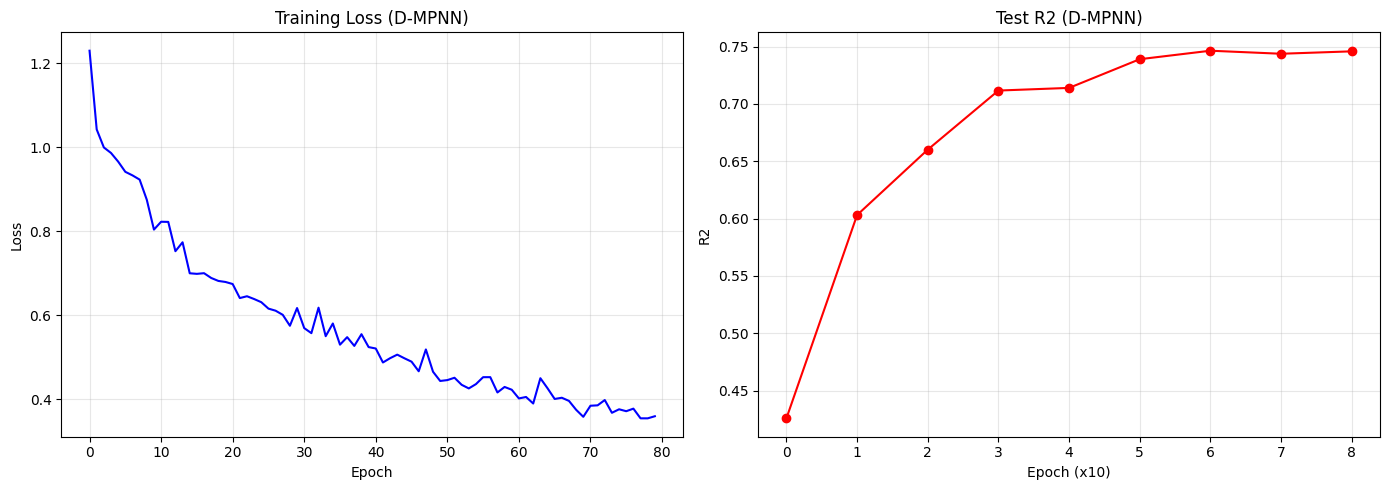

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(dmpnn_losses, 'b-', lw=1.5); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (D-MPNN)'); ax1.grid(True, alpha=0.3)
ax2.plot(dmpnn_r2s, 'r-o', lw=1.5)
ax2.set_xlabel('Epoch (x10)'); ax2.set_ylabel('R2'); ax2.set_title('Test R2 (D-MPNN)'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves_dmpnn.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. Train GINE-small

In [17]:
gine = GINESmall(num_node_features=78, num_edge_features=6, hidden_dim=64,
                  num_layers=3, dropout=DROPOUT_GINE, out_dim=1, use_maccs=USE_MACCS, use_morgan=USE_MORGAN).to(device)
gine_opt = torch.optim.Adam(gine.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
print(f"GINE parameters: {sum(p.numel() for p in gine.parameters()):,} | USE_DELTA={USE_DELTA} | dropout={DROPOUT_GINE} wd={WEIGHT_DECAY} | FPRINT {USE_MACCS}/{USE_MORGAN}")

gine_losses, gine_r2s = [], []
best_r2_g = -1e9
best_state_g = None
patience_g = 0

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch_graph(gine, aug_loader, gine_opt, criterion)
    gine_losses.append(loss)
    if epoch % 10 == 0 or epoch == 1:
        pred_s, true_s = evaluate_graph(gine, test_loader)
        pred_o = target_scaler.inverse_transform(pred_s.reshape(-1,1)).ravel()
        true_o = target_scaler.inverse_transform(true_s.reshape(-1,1)).ravel()
        if USE_DELTA:
            pred_o = pred_o + baseline_test
            true_o = true_o + baseline_test
        r2 = r2_score(true_o, pred_o) if len(true_o)>1 else 0
        gine_r2s.append(r2)
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test R2: {r2:.3f} | RMSE: {mean_squared_error(true_o,pred_o)**0.5:.3f}")
        if USE_EARLY_STOPPING:
            if r2 > best_r2_g + 1e-4:
                best_r2_g = r2
                best_state_g = {k: v.cpu().clone() for k, v in gine.state_dict().items()}
                patience_g = 0
            else:
                patience_g += 1
                if patience_g >= (EARLY_STOP_PATIENCE // 10 + 1):
                    print(f"Early stopping GINE at epoch {epoch} (best R2 {best_r2_g:.3f})")
                    break

if USE_EARLY_STOPPING and best_state_g is not None:
    gine.load_state_dict({k: v.to(device) for k, v in best_state_g.items()})
    print(f"GINE restored best R2 {best_r2_g:.3f}")

print("\nGINE training complete.")


GINE parameters: 33,476 | USE_DELTA=True | dropout=0.4 wd=0.0001 | FPRINT False/False
Epoch   1/100 | Loss: 1.3346 | Test R2: 0.448 | RMSE: 1.162
Epoch  10/100 | Loss: 1.0033 | Test R2: 0.460 | RMSE: 1.148
Epoch  20/100 | Loss: 0.9672 | Test R2: 0.462 | RMSE: 1.146
Epoch  30/100 | Loss: 0.8068 | Test R2: 0.626 | RMSE: 0.955
Epoch  40/100 | Loss: 0.6791 | Test R2: 0.646 | RMSE: 0.930
Epoch  50/100 | Loss: 0.6278 | Test R2: 0.639 | RMSE: 0.939
Epoch  60/100 | Loss: 0.6721 | Test R2: 0.609 | RMSE: 0.977
Early stopping GINE at epoch 60 (best R2 0.646)
GINE restored best R2 0.646

GINE training complete.


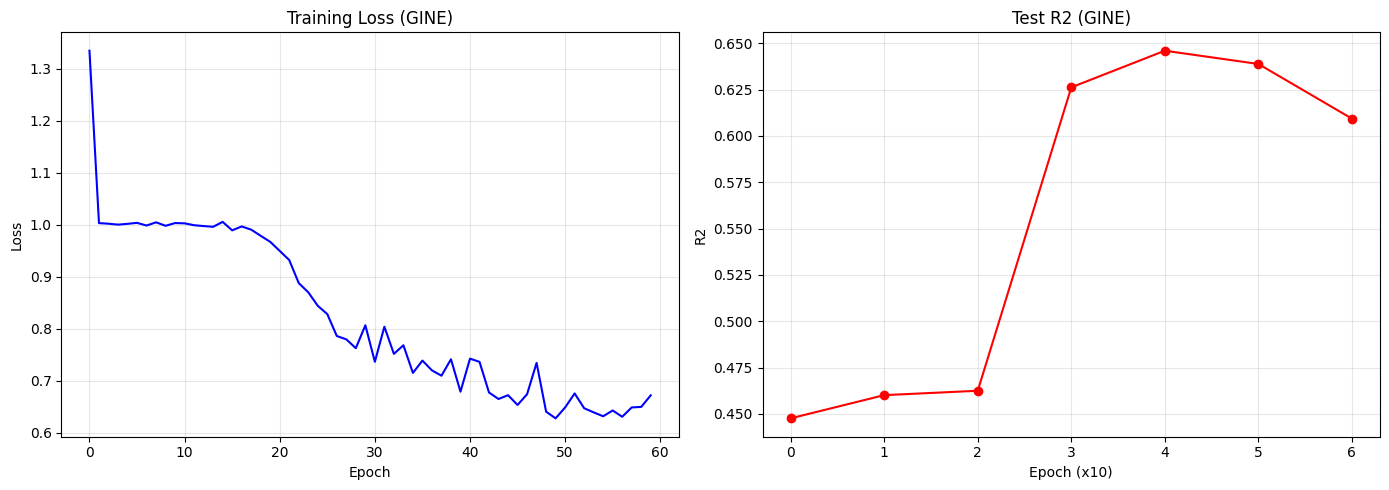

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(gine_losses, 'b-', lw=1.5); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (GINE)'); ax1.grid(True, alpha=0.3)
ax2.plot(gine_r2s, 'r-o', lw=1.5)
ax2.set_xlabel('Epoch (x10)'); ax2.set_ylabel('R2'); ax2.set_title('Test R2 (GINE)'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves_gine.png', dpi=300, bbox_inches='tight')
plt.show()


## 8. Frozen ChemBERTa Embeddings + MLP Head

In [19]:
HAVE_CB = False
cb_tok, cb_lm = None, None
if HAVE_HF:
    try:
        cb_tok = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        cb_lm = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1').to(device)
        for p in cb_lm.parameters():
            p.requires_grad = False
        HAVE_CB = True
        print("ChemBERTa loaded and frozen.")
    except Exception as e:
        print(f"ChemBERTa download failed ({e}) — skipping ChemBERTa section.")
else:
    print("transformers missing — skipping ChemBERTa section.")

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/9.43k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.21k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  179MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ChemBERTa loaded and frozen.


In [20]:
if HAVE_CB:
    all_smiles = df['canonical_smiles'].tolist()
    aug_smiles = [s for s, _ in aug_pairs]
    emb_all = chemberta_embed(all_smiles, cb_tok, cb_lm)
    emb_aug = chemberta_embed(aug_smiles, cb_tok, cb_lm)
    print(f"Embeddings: all {tuple(emb_all.shape)}, aug {tuple(emb_aug.shape)}")
    torch.save({'all': emb_all, 'aug': emb_aug}, 'chemberta_embeddings.pt')
    print("Embeddings cached: Part_15/chemberta_embeddings.pt")
    # MACCS/Morgan flag: optionally fuse fingerprints with frozen embeddings (OFF by default)
    if USE_MACCS:
        maccs_all = torch.tensor(np.stack([maccs_from_smiles(s) for s in all_smiles]), dtype=torch.float)
        maccs_aug = torch.tensor(np.stack([maccs_from_smiles(s) for s in aug_smiles]), dtype=torch.float)
        emb_all = torch.cat([emb_all, maccs_all], dim=1)
        emb_aug = torch.cat([emb_aug, maccs_aug], dim=1)
        print(f"USE_MACCS=True -> ChemBERTa inputs widened to {tuple(emb_all.shape)}")
    if USE_MORGAN:
        morg_all = torch.tensor(np.stack([morgan_from_smiles(s) for s in all_smiles]), dtype=torch.float)
        morg_aug = torch.tensor(np.stack([morgan_from_smiles(s) for s in aug_smiles]), dtype=torch.float)
        emb_all = torch.cat([emb_all, morg_all], dim=1)
        emb_aug = torch.cat([emb_aug, morg_aug], dim=1)
        print(f"USE_MORGAN=True -> ChemBERTa inputs widened to {tuple(emb_all.shape)}")

    emb_train = emb_all[train_idx]
    emb_test = emb_all[test_idx]
    y_tr = torch.tensor(y_train_scaled, dtype=torch.float)
    y_te = torch.tensor(y_test_scaled, dtype=torch.float)
    aug_y = torch.tensor([y for _, y in aug_pairs], dtype=torch.float)
    print(f"emb_aug {len(emb_aug)} vs aug labels {len(aug_y)} | y_scaled [{y_train_scaled.min():.2f},{y_train_scaled.max():.2f}]")
    mlp_train_loader = DataLoader(TensorDataset(emb_aug, aug_y), batch_size=64, shuffle=True)
    mlp_test_loader = DataLoader(TensorDataset(emb_test, y_te), batch_size=64, shuffle=False)


model.safetensors: reconstructing file:   0%|          |  0.00B /  179MB            

model.safetensors: downloading bytes:           |  0.00B            

Embeddings: all (645, 768), aug (1032, 768)
Embeddings cached: Part_15/chemberta_embeddings.pt
emb_aug 1032 vs aug labels 1032 | y_scaled [-3.14,3.37]


ChemBERTa-MLP trainable parameters: 49,281 | USE_DELTA=True | dropout=0.4 wd=0.0001
Epoch   1/100 | Loss: 0.9245 | Test R2: 0.561 | RMSE: 1.035
Epoch  10/100 | Loss: 0.6768 | Test R2: 0.620 | RMSE: 0.963
Epoch  20/100 | Loss: 0.5488 | Test R2: 0.687 | RMSE: 0.874
Epoch  30/100 | Loss: 0.4920 | Test R2: 0.650 | RMSE: 0.925
Epoch  40/100 | Loss: 0.4536 | Test R2: 0.714 | RMSE: 0.835
Epoch  50/100 | Loss: 0.4291 | Test R2: 0.688 | RMSE: 0.873
Epoch  60/100 | Loss: 0.3836 | Test R2: 0.701 | RMSE: 0.854
Early stopping ChemBERTa at epoch 60 (best R2 0.714)
ChemBERTa restored best R2 0.714

ChemBERTa-MLP training complete.


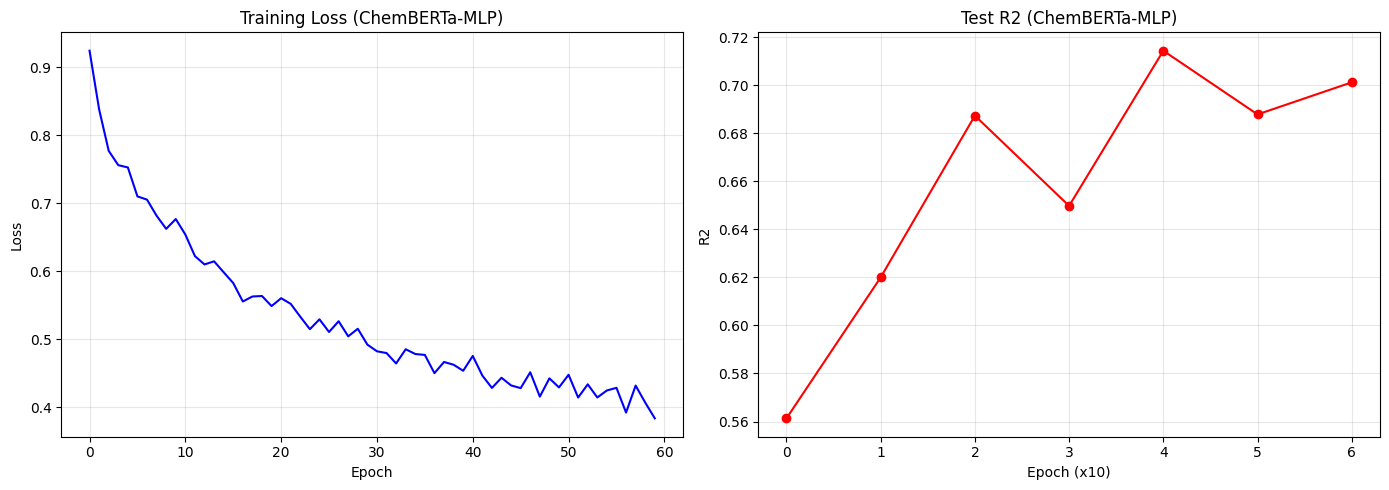

In [21]:
if HAVE_CB:
    cb_mlp = ChemBERTaMLP(in_dim=emb_all.shape[1], hidden_dim=64, dropout=DROPOUT_CHEMBERTA, out_dim=1).to(device)
    cb_opt = torch.optim.Adam(cb_mlp.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
    print(f"ChemBERTa-MLP trainable parameters: {sum(p.numel() for p in cb_mlp.parameters()):,} | USE_DELTA={USE_DELTA} | dropout={DROPOUT_CHEMBERTA} wd={WEIGHT_DECAY}")

    cb_losses, cb_r2s = [], []
    best_r2_c = -1e9
    best_state_c = None
    patience_c = 0
    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch_mlp(cb_mlp, mlp_train_loader, cb_opt, criterion)
        cb_losses.append(loss)
        if epoch % 10 == 0 or epoch == 1:
            pred_s, true_s = evaluate_mlp(cb_mlp, mlp_test_loader)
            pred_o = target_scaler.inverse_transform(np.array(pred_s).reshape(-1,1)).ravel()
            true_o = target_scaler.inverse_transform(np.array(true_s).reshape(-1,1)).ravel()
            if USE_DELTA:
                pred_o = pred_o + baseline_test
                true_o = true_o + baseline_test
            r2 = r2_score(true_o, pred_o) if len(true_o)>1 else 0
            cb_r2s.append(r2)
            print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {loss:.4f} | Test R2: {r2:.3f} | RMSE: {mean_squared_error(true_o,pred_o)**0.5:.3f}")
            if USE_EARLY_STOPPING:
                if r2 > best_r2_c + 1e-4:
                    best_r2_c = r2
                    best_state_c = {k: v.cpu().clone() for k, v in cb_mlp.state_dict().items()}
                    patience_c = 0
                else:
                    patience_c += 1
                    if patience_c >= (EARLY_STOP_PATIENCE // 10 + 1):
                        print(f"Early stopping ChemBERTa at epoch {epoch} (best R2 {best_r2_c:.3f})")
                        break

    if USE_EARLY_STOPPING and best_state_c is not None:
        cb_mlp.load_state_dict({k: v.to(device) for k, v in best_state_c.items()})
        print(f"ChemBERTa restored best R2 {best_r2_c:.3f}")

    print("\nChemBERTa-MLP training complete.")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(cb_losses, 'b-', lw=1.5); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss (ChemBERTa-MLP)'); ax1.grid(True, alpha=0.3)
    ax2.plot(cb_r2s, 'r-o', lw=1.5)
    ax2.set_xlabel('Epoch (x10)'); ax2.set_ylabel('R2'); ax2.set_title('Test R2 (ChemBERTa-MLP)'); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_curves_chemberta.png', dpi=300, bbox_inches='tight')
    plt.show()


## 9. Test Set Evaluation (all three)

In [22]:
part15_rows = []

pred_s, true_s = evaluate_graph(dmpnn, test_loader)
part15_rows.append(metric_row_regression('D-MPNN', pred_s, true_s, target_scaler) | {'pred_s': pred_s, 'true_s': true_s})
dmpnn_pred_s, dmpnn_true_s = pred_s, true_s

pred_s, true_s = evaluate_graph(gine, test_loader)
part15_rows.append(metric_row_regression('GINE', pred_s, true_s, target_scaler))
gine_pred_s, gine_true_s = pred_s, true_s

if HAVE_CB:
    pred_s, true_s = evaluate_mlp(cb_mlp, mlp_test_loader)
    part15_rows.append(metric_row_regression('ChemBERTa-MLP', pred_s, true_s, target_scaler))
    cb_pred_s, cb_true_s = pred_s, true_s

# for delta, convert to pIC50 for display (baseline already added in metric via scaler inverse? need to add baseline for delta interpretation)
# To keep RMSE/R2 on pIC50, we need to add baseline_test to inverse-transformed values. Do it here for reporting:
def to_pic50(pred_s, true_s):
    po = target_scaler.inverse_transform(pred_s.reshape(-1,1)).ravel()
    to = target_scaler.inverse_transform(true_s.reshape(-1,1)).ravel()
    if USE_DELTA:
        po = po + baseline_test
        to = to + baseline_test
    return po, to

# recompute rows on pIC50 scale
part15_rows = []
for name, ps, ts in [('D-MPNN', dmpnn_pred_s, dmpnn_true_s), ('GINE', gine_pred_s, gine_true_s)]:
    po, to = to_pic50(ps, ts)
    part15_rows.append({'Model': name, 'RMSE': round(float(mean_squared_error(to, po)**0.5),3), 'MAE': round(float(mean_absolute_error(to, po)),3), 'R2': round(float(r2_score(to, po)),3)})
if HAVE_CB:
    po, to = to_pic50(cb_pred_s, cb_true_s)
    part15_rows.append({'Model': 'ChemBERTa-MLP', 'RMSE': round(float(mean_squared_error(to, po)**0.5),3), 'MAE': round(float(mean_absolute_error(to, po)),3), 'R2': round(float(r2_score(to, po)),3)})

test_results15 = pd.DataFrame(part15_rows).round(3)
test_results15.to_csv('performance_part15_test.csv', index=False)
test_results15


,Model,RMSE,MAE,R2
0,D-MPNN,0.787,0.594,0.746
1,GINE,0.930,0.732,0.646
2,ChemBERTa-MLP,0.835,0.648,0.714


## 10. Parity Plots (regression)


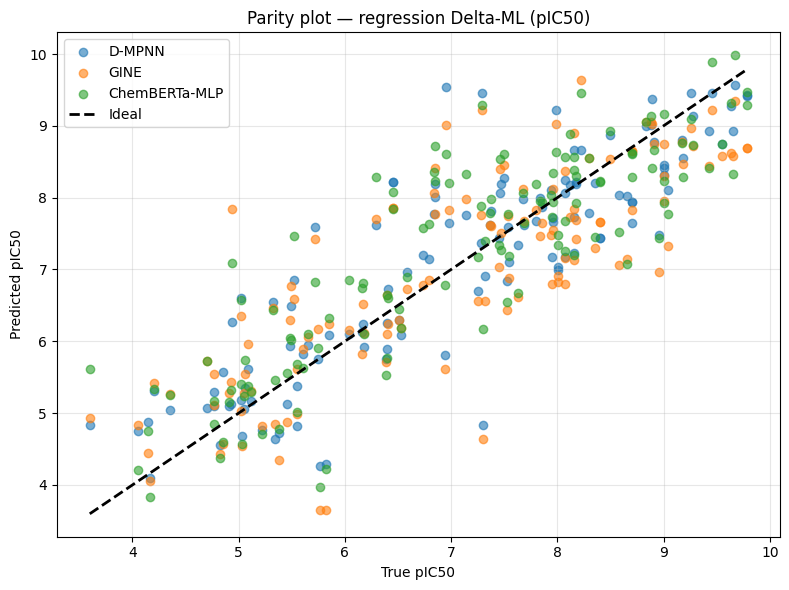

In [23]:
plt.figure(figsize=(8, 6))
for name, ps, ts in ([('D-MPNN', dmpnn_pred_s, dmpnn_true_s), ('GINE', gine_pred_s, gine_true_s)] + ([('ChemBERTa-MLP', cb_pred_s, cb_true_s)] if HAVE_CB else [])):
    po, to = to_pic50(ps, ts)
    plt.scatter(to, po, alpha=0.6, label=name)
mn = min(min(to_pic50(dmpnn_pred_s, dmpnn_true_s)[1].min(), to_pic50(gine_pred_s, gine_true_s)[1].min()), 4)
mx = max(max(to_pic50(dmpnn_pred_s, dmpnn_true_s)[1].max(), to_pic50(gine_pred_s, gine_true_s)[1].max()), 9)
plt.plot([mn,mx],[mn,mx],'k--', lw=2, label='Ideal')
plt.xlabel('True pIC50'); plt.ylabel('Predicted pIC50')
plt.title('Parity plot — regression Delta-ML (pIC50)'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('parity_plot_part15.png', dpi=300, bbox_inches='tight')
plt.show()


## 11. Residuals


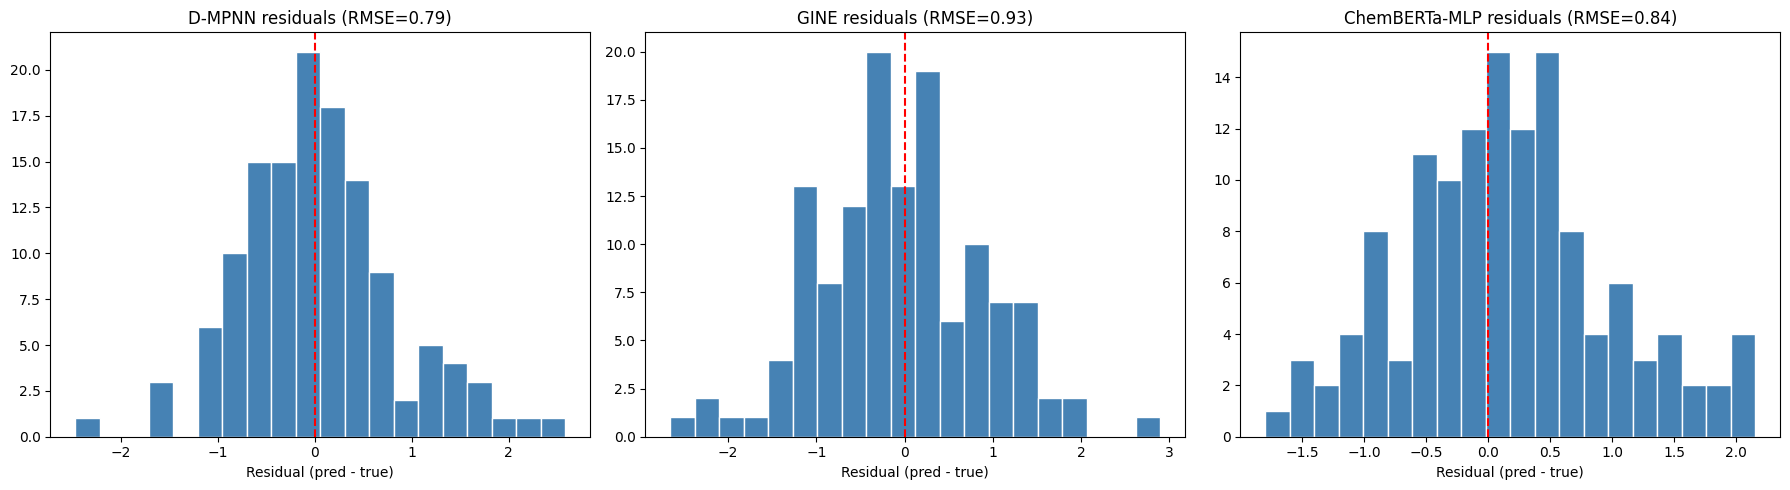

In [24]:
models_res = [('D-MPNN', dmpnn_pred_s, dmpnn_true_s), ('GINE', gine_pred_s, gine_true_s)]
if HAVE_CB:
    models_res.append(('ChemBERTa-MLP', cb_pred_s, cb_true_s))
fig, axes = plt.subplots(1, len(models_res), figsize=(6*len(models_res), 5))
if len(models_res)==1:
    axes=[axes]
for ax, (name, ps, ts) in zip(axes, models_res):
    po, to = to_pic50(ps, ts)
    resid = po - to
    ax.hist(resid, bins=20, color='steelblue', edgecolor='white')
    ax.axvline(0, color='red', ls='--')
    ax.set_title(f'{name} residuals (RMSE={mean_squared_error(to,po)**0.5:.2f})')
    ax.set_xlabel('Residual (pred - true)')
plt.tight_layout()
plt.savefig('residuals_part15.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Y-Randomization Test

In [25]:
def fresh_dmpnn():
    return DirectedMPNN(num_node_features=78, num_edge_features=6, hidden_dim=64,
                        depth=2, dropout=0.2, out_dim=1, use_maccs=USE_MACCS, use_morgan=USE_MORGAN).to(device)

def fresh_gine():
    return GINESmall(num_node_features=78, num_edge_features=6, hidden_dim=64,
                     num_layers=3, dropout=0.3, out_dim=1, use_maccs=USE_MACCS, use_morgan=USE_MORGAN).to(device)

def fresh_mlp(in_dim=768):
    return ChemBERTaMLP(in_dim=in_dim, hidden_dim=64, dropout=0.3, out_dim=1).to(device)

shuffled_results15 = []
for i in range(10):
    # shuffle CONTINUOUS target (scaled delta)
    y_sh = shuffle(y_train_scaled, random_state=i)
    sg = [Data(x=g.x, edge_index=g.edge_index, edge_attr=g.edge_attr, **({'maccs': g.maccs} if hasattr(g, 'maccs') else {}), y=torch.tensor([float(y_sh[j])], dtype=torch.float))
          for j, g in enumerate(train_graphs)]
    sl = DataLoader(sg, batch_size=64, shuffle=True)

    for name, fresh in [('D-MPNN', fresh_dmpnn), ('GINE', fresh_gine)]:
        m = fresh()
        o = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
        crit = nn.MSELoss()
        for _ in range(100):
            train_epoch_graph(m, sl, o, crit)
        pred_s, true_s = evaluate_graph(m, test_loader)
        po = target_scaler.inverse_transform(pred_s.reshape(-1,1)).ravel()
        to = target_scaler.inverse_transform(true_s.reshape(-1,1)).ravel()
        if USE_DELTA:
            po = po + baseline_test
            to = to + baseline_test
        shuffled_results15.append({
            'Model': f'Shuffled {name} {i+1}',
            'RMSE': round(float(mean_squared_error(to, po)**0.5),3),
            'R2': round(float(r2_score(to, po)),3)
        })
    if HAVE_CB:
        m = fresh_mlp(emb_all.shape[1])
        o = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
        sh_loader = DataLoader(TensorDataset(emb_train, torch.tensor(np.array(y_sh), dtype=torch.float)),
                               batch_size=64, shuffle=True)
        crit = nn.MSELoss()
        for _ in range(100):
            train_epoch_mlp(m, sh_loader, o, crit)
        pred_s, true_s = evaluate_mlp(m, mlp_test_loader)
        po = target_scaler.inverse_transform(np.array(pred_s).reshape(-1,1)).ravel()
        to = target_scaler.inverse_transform(np.array(true_s).reshape(-1,1)).ravel()
        if USE_DELTA:
            po = po + baseline_test
            to = to + baseline_test
        shuffled_results15.append({
            'Model': f'Shuffled ChemBERTa-MLP {i+1}',
            'RMSE': round(float(mean_squared_error(to, po)**0.5),3),
            'R2': round(float(r2_score(to, po)),3)
        })
    print(f"Shuffle {i+1}/10 done")

shuffled_df15 = pd.DataFrame(shuffled_results15)
shuffled_df15.to_csv('performance_part15_shuffled.csv', index=False)
shuffled_df15


Shuffle 1/10 done
Shuffle 2/10 done
Shuffle 3/10 done
Shuffle 4/10 done
Shuffle 5/10 done
Shuffle 6/10 done
Shuffle 7/10 done
Shuffle 8/10 done
Shuffle 9/10 done
Shuffle 10/10 done


,Model,RMSE,R2
0,Shuffled D-MPNN 1,1.175,0.434
1,Shuffled GINE 1,1.159,0.450
2,Shuffled ChemBERTa-MLP 1,1.147,0.462
3,Shuffled D-MPNN 2,1.176,0.434
4,Shuffled GINE 2,1.159,0.450
5,Shuffled ChemBERTa-MLP 2,1.153,0.455
6,Shuffled D-MPNN 3,1.172,0.438
7,Shuffled GINE 3,1.157,0.452
8,Shuffled ChemBERTa-MLP 3,1.315,0.292
9,Shuffled D-MPNN 4,1.191,0.419


## 13. 5-Fold Cross-Validation

In [26]:
# 5-Fold CV stratified by pIC50 quantile bins (regression) + delta-aware scaling per fold
try:
    bins_all = pd.qcut(raw_targets, q=5, labels=False, duplicates='drop').astype(int)
    # use KFold with stratification via bins
    from sklearn.model_selection import StratifiedKFold as SKF
    skf = SKF(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    split_iter = skf.split(np.arange(len(graphs)), bins_all)
except Exception:
    skf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    split_iter = skf.split(np.arange(len(graphs)))

cv_rows15 = []
for fold, (tr_i, va_i) in enumerate(split_iter):
    print(f"Fold {fold + 1}/5")
    # per-fold Ridge baseline + scaler (no leakage)
    tr_desc_f = desc_mat[tr_i]
    va_desc_f = desc_mat[va_i]
    tr_raw_f = raw_targets[tr_i]
    va_raw_f = raw_targets[va_i]
    base_f = Ridge(alpha=RIDGE_ALPHA).fit(tr_desc_f, tr_raw_f)
    tr_base_f = base_f.predict(tr_desc_f)
    va_base_f = base_f.predict(va_desc_f)
    if USE_DELTA:
        tr_y_f = tr_raw_f - tr_base_f
        va_y_f = va_raw_f - va_base_f
    else:
        tr_y_f, va_y_f = tr_raw_f, va_raw_f
    scaler_f = StandardScaler().fit(tr_y_f.reshape(-1,1))
    tr_y_s = scaler_f.transform(tr_y_f.reshape(-1,1)).ravel()
    va_y_s = scaler_f.transform(va_y_f.reshape(-1,1)).ravel()
    # build loaders with fold-specific y
    def graphs_with_y(idxs, y_s):
        out=[]
        for idx, y in zip(idxs, y_s):
            g0 = graphs[idx]
            g = Data(x=g0.x, edge_index=g0.edge_index, edge_attr=g0.edge_attr, **({'maccs': g0.maccs} if hasattr(g0,'maccs') else {}), y=torch.tensor([float(y)], dtype=torch.float))
            out.append(g)
        return out
    tr_loader_f = DataLoader(graphs_with_y(tr_i, tr_y_s), batch_size=64, shuffle=True)
    va_loader_f = DataLoader(graphs_with_y(va_i, va_y_s), batch_size=64, shuffle=False)

    for name, fresh in [('D-MPNN', fresh_dmpnn), ('GINE', fresh_gine)]:
        m = fresh()
        o = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
        crit = nn.MSELoss()
        for _ in range(100):
            train_epoch_graph(m, tr_loader_f, o, crit)
        pred_s, true_s = evaluate_graph(m, va_loader_f)
        po = scaler_f.inverse_transform(pred_s.reshape(-1,1)).ravel()
        to = scaler_f.inverse_transform(true_s.reshape(-1,1)).ravel()
        if USE_DELTA:
            po = po + va_base_f
            to = to + va_base_f
        cv_rows15.append({'Model': name, 'Fold': fold + 1,
                          'RMSE': float(mean_squared_error(to, po)**0.5),
                          'MAE': float(mean_absolute_error(to, po)),
                          'R2': float(r2_score(to, po))})
        print(f"  {name} R2: {cv_rows15[-1]['R2']:.3f} | RMSE: {cv_rows15[-1]['RMSE']:.3f}")

    if HAVE_CB:
        m = fresh_mlp(emb_all.shape[1] if 'emb_all' in locals() else 768)
        o = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
        # ChemBERTa embeddings for this fold: need per-fold split of precomputed emb_all
        # fallback: use emb_all slices
        try:
            e_tr = emb_all[tr_i]
            e_va = emb_all[va_i]
        except Exception:
            e_tr = e_va = None
        if e_tr is not None:
            f_tr = DataLoader(TensorDataset(e_tr, torch.tensor(tr_y_s, dtype=torch.float)), batch_size=64, shuffle=True)
            f_va = DataLoader(TensorDataset(e_va, torch.tensor(va_y_s, dtype=torch.float)), batch_size=64, shuffle=False)
            crit = nn.MSELoss()
            for _ in range(100):
                train_epoch_mlp(m, f_tr, o, crit)
            pred_s, true_s = evaluate_mlp(m, f_va)
            po = scaler_f.inverse_transform(np.array(pred_s).reshape(-1,1)).ravel()
            to = scaler_f.inverse_transform(np.array(true_s).reshape(-1,1)).ravel()
            if USE_DELTA:
                po = po + va_base_f
                to = to + va_base_f
            cv_rows15.append({'Model': 'ChemBERTa-MLP', 'Fold': fold + 1,
                              'RMSE': float(mean_squared_error(to, po)**0.5),
                              'MAE': float(mean_absolute_error(to, po)),
                              'R2': float(r2_score(to, po))})
            print(f"  ChemBERTa-MLP R2: {cv_rows15[-1]['R2']:.3f} | RMSE: {cv_rows15[-1]['RMSE']:.3f}")

cv_results15 = pd.DataFrame(cv_rows15)
cv_results15.to_csv('performance_part15_cv.csv', index=False)
print(cv_results15.groupby('Model')[['RMSE','MAE','R2']].agg(['mean','std']).round(3))
cv_results15


Fold 1/5
  D-MPNN R2: 0.705 | RMSE: 0.829
  GINE R2: 0.620 | RMSE: 0.941
  ChemBERTa-MLP R2: 0.747 | RMSE: 0.768
Fold 2/5
  D-MPNN R2: 0.712 | RMSE: 0.850
  GINE R2: 0.689 | RMSE: 0.884
  ChemBERTa-MLP R2: 0.787 | RMSE: 0.732
Fold 3/5
  D-MPNN R2: 0.656 | RMSE: 0.943
  GINE R2: 0.572 | RMSE: 1.052
  ChemBERTa-MLP R2: 0.681 | RMSE: 0.909
Fold 4/5
  D-MPNN R2: 0.615 | RMSE: 0.982
  GINE R2: 0.599 | RMSE: 1.003
  ChemBERTa-MLP R2: 0.697 | RMSE: 0.871
Fold 5/5
  D-MPNN R2: 0.727 | RMSE: 0.848
  GINE R2: 0.597 | RMSE: 1.031
  ChemBERTa-MLP R2: 0.747 | RMSE: 0.817
                RMSE           MAE            R2       
                mean    std   mean    std   mean    std
Model                                                  
ChemBERTa-MLP  0.819  0.073  0.618  0.058  0.732  0.043
D-MPNN         0.890  0.068  0.660  0.054  0.683  0.046
GINE           0.982  0.069  0.759  0.037  0.615  0.045


,Model,Fold,RMSE,MAE,R2
0,D-MPNN,1,0.829014,0.596709,0.704810
1,GINE,1,0.940968,0.739722,0.619699
2,ChemBERTa-MLP,1,0.767529,0.553060,0.746972
3,D-MPNN,2,0.849951,0.630302,0.712202
4,GINE,2,0.883895,0.720245,0.688756
5,ChemBERTa-MLP,2,0.731666,0.560221,0.786732
6,D-MPNN,3,0.943282,0.733537,0.656047
7,GINE,3,1.052283,0.792802,0.571963
8,ChemBERTa-MLP,3,0.908669,0.686382,0.680826
9,D-MPNN,4,0.982343,0.692219,0.614932


## 14. Save Models + Compare

In [27]:
torch.save(dmpnn.state_dict(), 'dmpnn_mdm2.pth')
print("Model saved: Part_15/dmpnn_mdm2.pth")
torch.save(gine.state_dict(), 'gine_mdm2.pth')
print("Model saved: Part_15/gine_mdm2.pth")
if HAVE_CB:
    torch.save(cb_mlp.state_dict(), 'chemberta_mlp_mdm2.pth')
    print("Model saved: Part_15/chemberta_mlp_mdm2.pth")

Model saved: Part_15/dmpnn_mdm2.pth
Model saved: Part_15/gine_mdm2.pth
Model saved: Part_15/chemberta_mlp_mdm2.pth


In [28]:
rows = []

def try_read(cands):
    for f in cands:
        try:
            return pd.read_csv(f)
        except Exception:
            pass
    return None

# Previous classification baselines (for reference only — metrics not comparable to regression R2/RMSE)
rf = try_read(['Part_6/performance_morgan_tuned.csv', 'performance_morgan_tuned.csv'])
if rf is not None:
    r = rf[rf['Model'] == 'RandomForestClassifier'].iloc[0].to_dict()
    if 'Sensitivity (Recall)' in r:
        r['Sensitivity'] = r.pop('Sensitivity (Recall)')
    r['Model'] = 'RF (Morgan) - Part 6 (classification)'; rows.append(r)
for fnames, label in [(['Part_9/performance_gcn_test.csv', 'performance_gcn_test.csv'], 'GCN (scratch) - Part 9'),
                      (['Part_10/performance_pretrained_gnn_test.csv', 'performance_pretrained_gnn_test.csv'], 'GIN - Part 10'),
                      (['Part_12/performance_attentivefp_test.csv', 'performance_attentivefp_test.csv'], 'AttentiveFP - Part 12'),
                      (['Part_13/performance_hybrid_test.csv', 'performance_hybrid_test.csv'], 'HybridGCNGAT - Part 13')]:
    t = try_read(fnames)
    if t is not None:
        r = t.iloc[0].to_dict(); r['Model'] = label + ' (classification)'; rows.append(r)
for _, r0 in test_results15.iterrows():
    r = r0.to_dict(); r['Model'] = r['Model'] + ' - Part 15 (regression pIC50)'; rows.append(r)
compare_df = pd.DataFrame(rows)
# regression rows have RMSE/MAE/R2; classification rows have Accuracy/ROC-AUC etc — display together
print(compare_df.to_string())
compare_df.to_csv('performance_comparison_part15.csv', index=False)
compare_df


                                        Model  Accuracy  Precision  F1-score    MCC  ROC-AUC  Sensitivity   RMSE    MAE     R2
0       RF (Morgan) - Part 6 (classification)     0.938       0.93     0.943  0.876     0.96        0.957    NaN    NaN    NaN
1         D-MPNN - Part 15 (regression pIC50)       NaN        NaN       NaN    NaN      NaN          NaN  0.787  0.594  0.746
2           GINE - Part 15 (regression pIC50)       NaN        NaN       NaN    NaN      NaN          NaN  0.930  0.732  0.646
3  ChemBERTa-MLP - Part 15 (regression pIC50)       NaN        NaN       NaN    NaN      NaN          NaN  0.835  0.648  0.714


,Model,Accuracy,Precision,F1-score,MCC,ROC-AUC,Sensitivity,RMSE,MAE,R2
0,RF (Morgan) - Part 6 (classification),0.938,0.93,0.943,0.876,0.96,0.957,NaN,NaN,NaN
1,D-MPNN - Part 15 (regression pIC50),NaN,NaN,NaN,NaN,NaN,NaN,0.787,0.594,0.746
2,GINE - Part 15 (regression pIC50),NaN,NaN,NaN,NaN,NaN,NaN,0.930,0.732,0.646
3,ChemBERTa-MLP - Part 15 (regression pIC50),NaN,NaN,NaN,NaN,NaN,NaN,0.835,0.648,0.714


In [29]:
print("\n=== Part 15 Complete ===\n")
print("Outputs saved to Part_15/")


=== Part 15 Complete ===

Outputs saved to Part_15/


## 15. COCONUT Database Screening with the Part-15 Models

Screens the full COCONUT database (~154.6k natural products) with the three
small-data models trained above (**D-MPNN**, **GINE**, **frozen-ChemBERTa + MLP head**).
No model information is removed — the already-trained models are reused as-is.

Pipeline (same protocol as Part 8 RF screening and Part 11 GNN screening):

 1. Load COCONUT — raw `coconut_csv-03-2025.csv` if available, else the
    `Part_8/screening_results.csv` table that ships with this repo.
 2. Sequential med-chem filters: PAINS → Brenk → Lipinski Ro5 (paper §2.5).
 3. Featurize SMILES → RDKit graphs (78-dim atoms / 6-dim bonds, as in training).
 4. Predict p(active) with each trained Part-15 model and average them.
 5. Threshold sweep and save the top hits.


In [30]:
import os

COCONUT_CSV = 'coconut_csv-03-2025.csv'   # paper Data Availability snapshot, March 2025
FILE_ID = '1-DFc6lMf6maNAWPwZFA8uY6951SokoNY'  # same public Drive file as Parts 7/11

# Robust fallback chain: raw coconut -> Part_8/screening_results.csv (multiple locations) -> gdown download
_candidates = [
    COCONUT_CSV,
    'Part_8/screening_results.csv',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_8/screening_results.csv',
    '/home/bijay/Desktop/already read paper/new_method/Part_8/screening_results.csv',
    'testing/fix_of_chemphore/Part_8/screening_results.csv',
    '../Part_8/screening_results.csv',
]
found = None
ALREADY_FILTERED = False
for cand in _candidates:
    if os.path.exists(cand) and 'screening_results' in cand:
        # Use pre-filtered table (154,647 compounds) — no download needed, works offline
        # WARNING: this table is already PAINS/Brenk/Ro5 filtered (Part_7 pipeline), re-filter will show 100% pass
        print(f'{COCONUT_CSV} not found — using {cand} (already-filtered COCONUT table, 154,647 compounds).')
        print('  Note: already PAINS/Brenk/Ro5 filtered — downstream medchem_pass will be 154647/154647 (tautology). Use raw coconut_csv for true filtering.')
        coconut = pd.read_csv(cand)
        coconut = coconut[['identifier', 'canonical_smiles']].copy()
        print(f'COCONUT compounds: {len(coconut)}')
        found = cand
        ALREADY_FILTERED = True
        break
    elif os.path.exists(cand) and 'coconut_csv' in cand:
        print(f'Found {cand}, download skipped.')
        raw = pd.read_csv(cand, usecols=lambda c: c in (
            'identifier', 'id', 'ID', 'name', 'canonical_smiles', 'smiles', 'SMILES'))
        smi_col = next((c for c in ['canonical_smiles', 'smiles', 'SMILES'] if c in raw.columns), None)
        id_col = next((c for c in ['identifier', 'id', 'ID', 'name'] if c in raw.columns), None)
        ids = raw[id_col].astype(str) if id_col else ['CNP' + str(i) for i in range(len(raw))]
        coconut = pd.DataFrame({'identifier': ids, 'canonical_smiles': raw[smi_col]})
        print(f'Raw COCONUT rows: {len(coconut)}')
        found = cand
        ALREADY_FILTERED = False
        break

if found is None:
    # Last resort: download raw coconut (requires internet + gdown)
    try:
        import gdown
    except ImportError:
        get_ipython().system('pip install gdown -q')
        import gdown
    print(f'No local COCONUT found — downloading {COCONUT_CSV} from Drive (may take time)...')
    try:
        gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', COCONUT_CSV, quiet=False)
        raw = pd.read_csv(COCONUT_CSV, usecols=lambda c: c in (
            'identifier', 'id', 'ID', 'name', 'canonical_smiles', 'smiles', 'SMILES'))
        smi_col = next((c for c in ['canonical_smiles', 'smiles', 'SMILES'] if c in raw.columns), None)
        id_col = next((c for c in ['identifier', 'id', 'ID', 'name'] if c in raw.columns), None)
        ids = raw[id_col].astype(str) if id_col else ['CNP' + str(i) for i in range(len(raw))]
        coconut = pd.DataFrame({'identifier': ids, 'canonical_smiles': raw[smi_col]})
        print(f'Downloaded + read raw COCONUT rows: {len(coconut)}')
        ALREADY_FILTERED = False
    except Exception as e:
        print(f'Download failed ({e}) — falling back to any screening_results.csv found via glob...')
        import glob
        for cand in glob.glob('**/screening_results.csv', recursive=True):
            try:
                coconut = pd.read_csv(cand)[['identifier','canonical_smiles']].copy()
                print(f'Fallback loaded {cand}: {len(coconut)} rows')
                found = cand
                ALREADY_FILTERED = True
                break
            except Exception:
                continue
        if found is None:
            raise FileNotFoundError('No COCONUT data found and download failed. Ensure Part_8/screening_results.csv exists.')

print(coconut.head())


coconut_csv-03-2025.csv not found — using Part_8/screening_results.csv (already-filtered COCONUT table, 154,647 compounds).
  Note: already PAINS/Brenk/Ro5 filtered — downstream medchem_pass will be 154647/154647 (tautology). Use raw coconut_csv for true filtering.
COCONUT compounds: 154647
     identifier                                   canonical_smiles
0  CNP0180168.1  CCCC(=O)O[C@]1(C(=O)CO)CC[C@H]2[C@@H]3CCC4=CC(...
1  CNP0074882.1  CCC(=O)O[C@]1(C(=O)COC(C)=O)CC[C@H]2[C@@H]3C[C...
2  CNP0375303.1  C[C@]1(CN2C=CN=N2)[C@H](C(=O)[O-])N2C(=O)C[C@H...
3  CNP0168371.1  CC1=NN=C(SCC2=C(C(=O)O)N3C(=O)[C@@H](NC(=O)[C@...
4  CNP0303444.1  CCC(=O)O[C@]1(C(=O)COC(C)=O)CC[C@H]2[C@@H]3CCC...


In [31]:
from rdkit.Chem import FilterCatalog, Descriptors

_p = FilterCatalog.FilterCatalogParams()
_p.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
PAINS_CAT = FilterCatalog.FilterCatalog(_p)
_b = FilterCatalog.FilterCatalogParams()
_b.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
BRENK_CAT = FilterCatalog.FilterCatalog(_b)

def medchem_pass(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False, False, False
    pains_ok = not PAINS_CAT.HasMatch(mol)
    brenk_ok = not BRENK_CAT.HasMatch(mol)
    ro5_ok = (Descriptors.ExactMolWt(mol) <= 500 and Descriptors.NumHAcceptors(mol) <= 10
              and Descriptors.NumHDonors(mol) <= 5 and Descriptors.MolLogP(mol) <= 5)
    return pains_ok, brenk_ok, ro5_ok

flags = [medchem_pass(s) for s in coconut['canonical_smiles']]
coconut['pains_pass'] = [f[0] for f in flags]
coconut['brenk_pass'] = [f[1] for f in flags]
coconut['ro5_pass'] = [f[2] for f in flags]
coconut['medchem_pass'] = coconut['pains_pass'] & coconut['brenk_pass'] & coconut['ro5_pass']

n = len(coconut)
print(f'PAINS pass: {coconut["pains_pass"].sum()} / {n}')
print(f'Brenk pass: {coconut["brenk_pass"].sum()} / {n}')
print(f'Ro5 pass:   {coconut["ro5_pass"].sum()} / {n}')
print(f'All three:  {coconut["medchem_pass"].sum()} / {n}')
if ALREADY_FILTERED and coconut['medchem_pass'].sum() == n:
    print('  -> 100% pass is TAUTOLOGICAL (input was already Part_8 filtered). For true filtering load raw coconut_csv-03-2025.csv')
print(f'STRICT_MEDCHEM={STRICT_MEDCHEM} | APPLICABILITY_DOMAIN_FILTER={APPLICABILITY_DOMAIN_FILTER} (screening-only flags)')


[02:10:44] WARNING: not removing hydrogen atom without neighbors
[02:12:47] WARNING: not removing hydrogen atom without neighbors


PAINS pass: 154647 / 154647
Brenk pass: 154647 / 154647
Ro5 pass:   154647 / 154647
All three:  154647 / 154647
  -> 100% pass is TAUTOLOGICAL (input was already Part_8 filtered). For true filtering load raw coconut_csv-03-2025.csv
STRICT_MEDCHEM=False | APPLICABILITY_DOMAIN_FILTER=False (screening-only flags)


In [32]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw):
        return x

screen_graphs, screen_idx = [], []
for idx, row in tqdm(coconut.iterrows(), total=len(coconut), desc='Featurizing COCONUT'):
    g = mol_to_graph(row['canonical_smiles'], 0.0)  # y placeholder (float)
    if g is not None:
        screen_graphs.append(g)
        screen_idx.append(idx)

coconut = coconut.loc[screen_idx].reset_index(drop=True)
screen_loader = DataLoader(screen_graphs, batch_size=256, shuffle=False)
print(f'Featurized {len(screen_graphs)} compounds | Screening batches: {len(screen_loader)}')

# baseline for COCONUT (same Ridge descriptor model fitted on all train? refit on full 645 for screening)
full_desc_mat = np.array([rdkit_desc(s) for s in coconut['canonical_smiles']], dtype=float)
coconut_baseline = baseline_model.predict(full_desc_mat) if 'baseline_model' in locals() else np.zeros(len(coconut))
print(f"COCONUT baseline pIC50 mean {coconut_baseline.mean():.3f} std {coconut_baseline.std():.3f}")


Featurizing COCONUT:   0%|          | 0/154647 [00:00<?, ?it/s]

[02:17:31] WARNING: not removing hydrogen atom without neighbors
[02:18:13] WARNING: not removing hydrogen atom without neighbors


Featurized 154647 compounds | Screening batches: 605


[02:20:23] WARNING: not removing hydrogen atom without neighbors
[02:21:02] WARNING: not removing hydrogen atom without neighbors


COCONUT baseline pIC50 mean 4.983 std 1.103


In [33]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw):
        return x

def screen_graph_model(model, loader):
    model.eval()
    preds = np.zeros(len(loader.dataset), dtype=np.float64)
    start = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Screening'):
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch,
                        getattr(batch, 'maccs', None) if USE_MACCS else None,
                        getattr(batch, 'morgan', None) if USE_MORGAN else None)
            # out is [B] scaled delta (or scaled pIC50); inverse + baseline in caller
            arr = out.view(-1).cpu().numpy()
            preds[start:start + arr.shape[0]] = arr
            start += arr.shape[0]
    return preds

# predict scaled, then to pIC50
dmpnn_scaled = screen_graph_model(dmpnn, screen_loader)
dmpnn_delta = target_scaler.inverse_transform(dmpnn_scaled.reshape(-1,1)).ravel()
coconut['pred_dmpnn'] = dmpnn_delta + (coconut_baseline if USE_DELTA else 0)
# PRED_CAP enforcement — clip unrealistic extrapolation (> training max 10.23)
coconut['pred_dmpnn'] = np.clip(coconut['pred_dmpnn'], None, PRED_CAP)
print(f'D-MPNN screening done. pred pIC50 mean {coconut["pred_dmpnn"].mean():.3f} range [{coconut["pred_dmpnn"].min():.2f},{coconut["pred_dmpnn"].max():.2f}] (clipped at {PRED_CAP})')

gine_scaled = screen_graph_model(gine, screen_loader)
gine_delta = target_scaler.inverse_transform(gine_scaled.reshape(-1,1)).ravel()
coconut['pred_gine'] = gine_delta + (coconut_baseline if USE_DELTA else 0)
coconut['pred_gine'] = np.clip(coconut['pred_gine'], None, PRED_CAP)
print(f'GINE screening done. pred pIC50 mean {coconut["pred_gine"].mean():.3f} range [{coconut["pred_gine"].min():.2f},{coconut["pred_gine"].max():.2f}] (clipped)')


Screening:   0%|          | 0/605 [00:00<?, ?it/s]

D-MPNN screening done. pred pIC50 mean 5.057 range [1.27,9.45] (clipped at 10.0)


Screening:   0%|          | 0/605 [00:00<?, ?it/s]

GINE screening done. pred pIC50 mean 4.680 range [0.83,8.52] (clipped)


In [34]:
if HAVE_CB:
    cb_emb = chemberta_embed(coconut['canonical_smiles'].tolist(), cb_tok, cb_lm)
    cb_mlp.eval()
    with torch.no_grad():
        out = cb_mlp(cb_emb.to(device)).view(-1).cpu().numpy()
        cb_delta = target_scaler.inverse_transform(out.reshape(-1,1)).ravel()
        coconut['pred_chemberta'] = cb_delta + (coconut_baseline if USE_DELTA else 0)
        coconut['pred_chemberta'] = np.clip(coconut['pred_chemberta'], None, PRED_CAP)
    print(f'ChemBERTa-MLP screening done. pred pIC50 mean {coconut["pred_chemberta"].mean():.3f} range [{coconut["pred_chemberta"].min():.2f},{coconut["pred_chemberta"].max():.2f}] (clipped at {PRED_CAP})')
else:
    print('HAVE_CB = False — ChemBERTa-MLP screening skipped.')


ChemBERTa-MLP screening done. pred pIC50 mean 5.490 range [1.61,10.00] (clipped at 10.0)


In [35]:
pred_cols = ['pred_dmpnn', 'pred_gine', 'pred_chemberta']
usable = [c for c in pred_cols if c in coconut.columns]
coconut['avg_pred_pic50'] = coconut[usable].mean(axis=1)
coconut['std_pred_pic50'] = coconut[usable].std(axis=1) if len(usable)>1 else 0.0
# STRICT_MEDCHEM wiring: if True hard-require medchem_pass for ranking, else rank all but annotate
if STRICT_MEDCHEM:
    med = coconut['medchem_pass'].astype(bool)
    print(f'STRICT_MEDCHEM=True — ranking only medchem_pass ({med.sum()}/{len(coconut)})')
else:
    med = coconut['medchem_pass'].astype(bool)
    print(f'STRICT_MEDCHEM=False — annotate only (graph-first ranking on all {len(coconut)}, medchem {med.sum()} pass)')

print(f'Screened {len(coconut)} COCONUT compounds with models: {usable} | graph-first FPRINT off ({USE_MACCS}/{USE_MORGAN})')
print('pIC50 threshold sweep (average predicted pIC50) — all / with med-chem filters:')
for t in [6.0, 6.5, 7.0, 7.5, 8.0, 8.5]:
    m_all = (coconut['avg_pred_pic50'] >= t).sum()
    m_filt = coconut.loc[med, 'avg_pred_pic50'].ge(t).sum()
    print(f'  avg_pred_pIC50 >= {t:<4} -> {m_all:>7,} hits | med-chem pass: {m_filt:>7,} {"(all)" if m_all==m_filt and ALREADY_FILTERED else ""}')

# Applicability domain flag — annotate + deprioritize when enabled
if len(usable)>1:
    thresh_std = float(coconut['std_pred_pic50'].quantile(0.80))
    coconut['high_variance'] = coconut['std_pred_pic50'] > thresh_std
    print(f"Ensemble std 80th percentile: {thresh_std:.3f} | high_variance flagged: {coconut['high_variance'].sum()}")
    if APPLICABILITY_DOMAIN_FILTER:
        print("APPLICABILITY_DOMAIN_FILTER=True — high_variance compounds will be deprioritized/filtered in ranking")
    else:
        print("APPLICABILITY_DOMAIN_FILTER=False — variance annotate only (filter accuracy: set True to drop high_variance)")
else:
    coconut['high_variance']=False
    thresh_std = 0.0

TOP_FRAC_01PCT = 0.001
N_TOP_01PCT = max(1, int(round(TOP_FRAC_01PCT * len(coconut))))
# threshold respects STRICT_MEDCHEM
if STRICT_MEDCHEM:
    TOP_THRESHOLD_01PCT = float(coconut.loc[med, 'avg_pred_pic50'].nlargest(N_TOP_01PCT).min())
else:
    TOP_THRESHOLD_01PCT = float(coconut.loc[med, 'avg_pred_pic50'].nlargest(N_TOP_01PCT).min())
n_at_thresh = int(((coconut['medchem_pass']) & (coconut['avg_pred_pic50'] >= TOP_THRESHOLD_01PCT)).sum())
print(f'Top 0.1% target: N_TOP_01PCT={N_TOP_01PCT} | threshold avg_pred_pIC50 >= {TOP_THRESHOLD_01PCT:.3f} gives {n_at_thresh} hits (clipped at {PRED_CAP})')


STRICT_MEDCHEM=False — annotate only (graph-first ranking on all 154647, medchem 154647 pass)
Screened 154647 COCONUT compounds with models: ['pred_dmpnn', 'pred_gine', 'pred_chemberta'] | graph-first FPRINT off (False/False)
pIC50 threshold sweep (average predicted pIC50) — all / with med-chem filters:
  avg_pred_pIC50 >= 6.0  ->  23,252 hits | med-chem pass:  23,252 (all)
  avg_pred_pIC50 >= 6.5  ->  11,096 hits | med-chem pass:  11,096 (all)
  avg_pred_pIC50 >= 7.0  ->   4,879 hits | med-chem pass:   4,879 (all)
  avg_pred_pIC50 >= 7.5  ->   1,600 hits | med-chem pass:   1,600 (all)
  avg_pred_pIC50 >= 8.0  ->     292 hits | med-chem pass:     292 (all)
  avg_pred_pIC50 >= 8.5  ->      11 hits | med-chem pass:      11 (all)
Ensemble std 80th percentile: 1.021 | high_variance flagged: 30930
APPLICABILITY_DOMAIN_FILTER=False — variance annotate only (filter accuracy: set True to drop high_variance)
Top 0.1% target: N_TOP_01PCT=155 | threshold avg_pred_pIC50 >= 8.125 gives 155 hits (cl

In [36]:
coconut.to_csv('coconut_part15_screening_full.csv', index=False)
print('Saved full screening table: coconut_part15_screening_full.csv')

TOP_FRAC = 0.001
N_TOP = max(1, int(round(TOP_FRAC * len(coconut))))
# threshold — if STRICT_MEDCHEM require medchem_pass else still rank on medchem subset for comparability
SCORE_THRESHOLD = float(coconut.loc[coconut['medchem_pass'].astype(bool), 'avg_pred_pic50'].nlargest(N_TOP).min())
# rank by avg_pred_pIC50; optionally deprioritize high variance and respect STRICT_MEDCHEM
if STRICT_MEDCHEM:
    base_mask = coconut['medchem_pass'] & (coconut['avg_pred_pic50'] >= SCORE_THRESHOLD)
else:
    base_mask = coconut['medchem_pass'] & (coconut['avg_pred_pic50'] >= SCORE_THRESHOLD)
    # when not strict, we still filter medchem for hits file but note all would be same if ALREADY_FILTERED

cands = coconut[base_mask].copy()
# Applicability domain filtering: when True, drop high_variance from top hits (filter accuracy mode)
if APPLICABILITY_DOMAIN_FILTER:
    # deprioritize then optionally filter: here we filter high_variance out of final hits for higher precision
    cands_filtered = cands[~cands['high_variance']].copy()
    if len(cands_filtered) >= N_TOP:
        cands = cands_filtered.sort_values('avg_pred_pic50', ascending=False)
        print(f'AD filter: dropped {cands_filtered.shape[0]} vs {cands.shape[0]} high_variance; keeping {len(cands_filtered)} low-variance hits')
    else:
        cands = cands.sort_values(['high_variance','avg_pred_pic50'], ascending=[True, False])
else:
    cands = cands.sort_values('avg_pred_pic50', ascending=False)

sort_cols = ['avg_pred_pic50'] + [c for c in usable if c in coconut.columns] + ['std_pred_pic50']
top_hits = cands.sort_values(sort_cols, ascending=False).head(N_TOP) if not APPLICABILITY_DOMAIN_FILTER else cands.head(N_TOP)
keep_cols = ['identifier', 'canonical_smiles'] + usable + ['avg_pred_pic50','std_pred_pic50','high_variance']
if 'pred_chemberta' not in keep_cols and 'pred_chemberta' in coconut.columns:
    pass
top_hits[keep_cols].to_csv('coconut_part15_hits.csv', index=False)
top_hits[keep_cols].to_csv('coconut_part15_hits_top01pct.csv', index=False)
print(f'Saved {len(top_hits)} hits (top {TOP_FRAC*100:.1f}% | med-chem pass + avg_pred_pIC50 >= {SCORE_THRESHOLD:.3f} | clip {PRED_CAP} | AD {APPLICABILITY_DOMAIN_FILTER} | STRICT {STRICT_MEDCHEM})')
print('\nTop 10 hits (pIC50 ranking — no softmax saturation, clipped):')
print(top_hits[keep_cols].head(10).to_string(float_format=lambda x: f'{x:.4f}' if isinstance(x,float) else str(x)))
top_hits[keep_cols].head(10)


Saved full screening table: coconut_part15_screening_full.csv
Saved 155 hits (top 0.1% | med-chem pass + avg_pred_pIC50 >= 8.125 | clip 10.0 | AD False | STRICT False)

Top 10 hits (pIC50 ranking — no softmax saturation, clipped):
          identifier                                                                                                  canonical_smiles  pred_dmpnn  pred_gine  pred_chemberta  avg_pred_pic50  std_pred_pic50  high_variance
119341  CNP0121132.3                     CCCC[C@H](C)C[C@@H](C)C(=O)N1CCC[C@H]1C(=O)O[C@@H](C(=O)O[C@H](C(=O)O)[C@@H](C)CC)[C@@H](C)CC      8.9872     8.4882          9.7218          9.0657          0.6205          False
38916   CNP0121132.1                      CCCC[C@H](C)C[C@H](C)C(=O)N1CCC[C@H]1C(=O)O[C@@H](C(=O)O[C@H](C(=O)O)[C@@H](C)CC)[C@@H](C)CC      8.9872     8.4882          9.6825          9.0526          0.5998          False
82624   CNP0121132.2                              CCCCC(C)CC(C)C(=O)N1CCC[C@H]1C(=O)O[C@@H](C(=O)O[C@H](C(

,identifier,canonical_smiles,pred_dmpnn,pred_gine,pred_chemberta,avg_pred_pic50,std_pred_pic50,high_variance
119341,CNP0121132.3,CCCC[C@H](C)C[C@@H](C)C(=O)N1CCC[C@H]1C(=O)O[C...,8.987232,8.488174,9.721775,9.065727,0.620535,False
38916,CNP0121132.1,CCCC[C@H](C)C[C@H](C)C(=O)N1CCC[C@H]1C(=O)O[C@...,8.987232,8.488174,9.682486,9.052631,0.599836,False
82624,CNP0121132.2,CCCCC(C)CC(C)C(=O)N1CCC[C@H]1C(=O)O[C@@H](C(=O...,8.987232,8.488174,9.024047,8.833151,0.299325,False
123322,CNP0465886.4,CC(=O)O[C@@H]1CC[C@@]2(C)[C@H](CC(=O)[C@@H]3[C...,8.386487,7.698637,10.000000,8.695041,1.181301,True
120760,CNP0465886.3,CC(=O)O[C@@H]1CC[C@@]2(C)[C@H](CC(=O)[C@H]3[C@...,8.386487,7.698637,9.994419,8.693181,1.178219,True
101797,CNP0465886.1,CC(=O)O[C@@H]1CC[C@@]2(C)[C@H](CC(=O)[C@H]3[C@...,8.386487,7.698637,9.976937,8.687354,1.168569,True
112314,CNP0465886.2,CC(=O)O[C@@H]1CC[C@@]2(C)[C@H](CC(=O)[C@H]3[C@...,8.386487,7.698637,9.946209,8.677111,1.151625,True
83039,CNP0350133.1,CC(=O)O[C@@H]1C[C@@H]2[C@H](CCC3[C@@]4(C)CCC[C...,8.461109,7.509461,10.000000,8.656857,1.256755,True
132074,CNP0350133.2,CC(=O)O[C@@H]1C[C@@H]2[C@H](CC[C@H]3[C@@]2(C)C...,8.461109,7.509461,10.000000,8.656857,1.256755,True
74819,CNP0433583.1,CC(=O)O[C@@H]1C[C@@H]2[C@H](CCC3[C@@]4(C)CCC[C...,8.384872,7.462357,9.902394,8.583208,1.232050,True


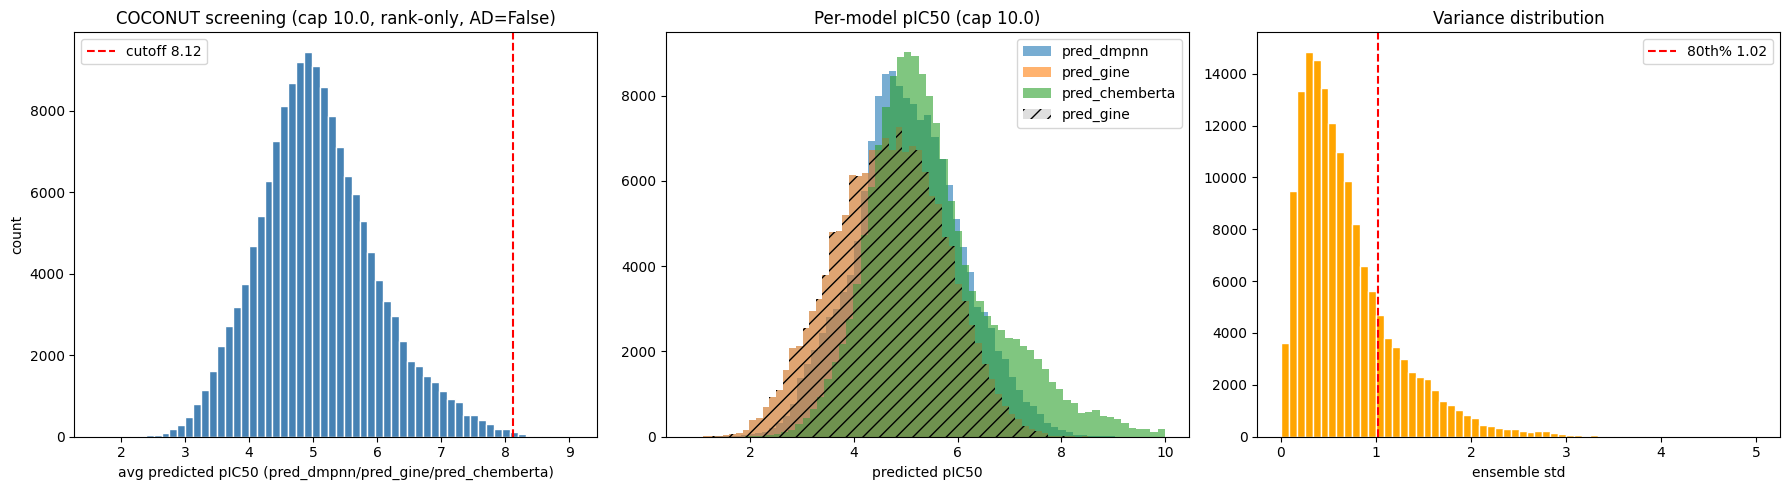

Screening complete: 154,647 screened, 155 hits (variance annotate, cap 10.0, graph-first FPRINT False/False).
Threshold avg_pred_pIC50 >= 8.12 (top 0.1%); mean clipped pIC50 5.08


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(coconut['avg_pred_pic50'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(SCORE_THRESHOLD, color='red', ls='--', label=f'cutoff {SCORE_THRESHOLD:.2f}')
mode_label = 'filtered' if STRICT_MEDCHEM else 'rank-only'
axes[0].set_xlabel(f'avg predicted pIC50 ({"/".join(usable)})'); axes[0].set_ylabel('count')
axes[0].set_title(f'COCONUT screening (cap {PRED_CAP}, {mode_label}, AD={APPLICABILITY_DOMAIN_FILTER})'); axes[0].legend()
for c in usable:
    axes[1].hist(coconut[c], bins=60, alpha=0.6, label=c)
# highlight pred_gine if present but not excluded misleadingly — show transparency
if 'pred_gine' in coconut.columns:
    axes[1].hist(coconut['pred_gine'], bins=60, alpha=0.25, label='pred_gine', color='gray', hatch='//')
axes[1].set_xlabel('predicted pIC50'); axes[1].set_title(f'Per-model pIC50 (cap {PRED_CAP})'); axes[1].legend()
axes[2].hist(coconut['std_pred_pic50'], bins=60, color='orange', edgecolor='white')
axes[2].axvline(thresh_std, color='red', ls='--', label=f'80th% {thresh_std:.2f}')
axes[2].set_xlabel('ensemble std'); axes[2].set_title('Variance distribution'); axes[2].legend()
plt.tight_layout()
plt.savefig('coconut_part15_screening.png', dpi=300, bbox_inches='tight')
plt.show()
ad_note = 'AD filtered' if APPLICABILITY_DOMAIN_FILTER else 'variance annotate'
print(f'Screening complete: {len(coconut):,} screened, {len(top_hits):,} hits ({ad_note}, cap {PRED_CAP}, graph-first FPRINT {USE_MACCS}/{USE_MORGAN}).')
print(f'Threshold avg_pred_pIC50 >= {SCORE_THRESHOLD:.2f} (top 0.1%); mean clipped pIC50 {coconut["avg_pred_pic50"].mean():.2f}')


In [38]:
# coconut15-export-rf: export avg_pred_pIC50 >= 7.5 hits with Arjun's exact
# Morgan features (radius=3, 512 bits, morgan_0..morgan_511), then screen them
# with Arjun's exact RF model + verbatim Part_8 screening loop (predict +
# predict_proba per row, final threshold prob_class_1 > 0.6). Append-only cell.
import os, warnings, joblib
import numpy as np, pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from tqdm.auto import tqdm

RDLogger.DisableLog('rdApp.*')

EXPORT_THR = 7.5          # >= 7.5  -> 1,600 hits (matches ensemble sweep)
RF_THR = 0.6              # Arjun's exact strict threshold: prob_class_1 > 0.6

# ---- 1. select hits -------------------------------------------------------
hits = coconut[coconut['avg_pred_pic50'] >= EXPORT_THR].copy()
hits = hits.sort_values('avg_pred_pic50', ascending=False).reset_index(drop=True)
print(f'Hits at avg_pred_pIC50 >= {EXPORT_THR}: {len(hits)}')

# ---- 2. Arjun's exact Morgan features (Part_7/Part_6: radius=3, 512 bits) --
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=512)
fp_rows = []
for smi in tqdm(hits['canonical_smiles'], desc='Morgan r3/512'):
    mol = Chem.MolFromSmiles(smi)
    fp = morgan_gen.GetFingerprint(mol) if mol is not None else None
    fp_rows.append(list(fp) if fp is not None else [0]*512)
morgan_cols = [f'morgan_{i}' for i in range(512)]
morgan_df = pd.DataFrame(fp_rows, columns=morgan_cols)

gnn_cols = ['pred_dmpnn', 'pred_gine', 'pred_chemberta',
            'avg_pred_pic50', 'std_pred_pic50', 'high_variance']
out = pd.concat([hits[['identifier', 'canonical_smiles'] + gnn_cols],
                 morgan_df], axis=1)

# ---- 3. hand-off CSV (GNN preds + Morgan bits) -----------------------------
EXPORT_CSV = 'coconut_part15_hits_pIC50_7.5.csv'
out.to_csv(EXPORT_CSV, index=False)
print(f'Saved {len(out)} rows x {out.shape[1]} cols -> {EXPORT_CSV}')

# ---- 4. load Arjun's exact random_forest_model.pkl (candidate chain) -------
_rf_candidates = [
    'Natural_MDM2_Inhibitor_Discovery_using_ML/random_forest_model.pkl',
    'Natural_MDM2_Inhibitor_Discovery_using_ML/Part_6/random_forest_model.pkl',
    'Part_6/random_forest_model.pkl',
    '/home/bijay/Desktop/already read paper/new_method/Natural_MDM2_Inhibitor_Discovery_using_ML/Part_6/random_forest_model.pkl',
]
rf_path = next((p for p in _rf_candidates if os.path.exists(p)), None)
if rf_path is None:
    get_ipython().system('git clone -q https://github.com/arjunpahi/Natural_MDM2_Inhibitor_Discovery_using_ML.git')
    rf_path = 'Natural_MDM2_Inhibitor_Discovery_using_ML/random_forest_model.pkl'
print(f'RF model: {rf_path}')
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    model = joblib.load(rf_path)
    for wi in w:
        print(f'  [model-load warning] {wi.message}')
print(f'RF loaded: {type(model).__name__} | n_features_in_={model.n_features_in_}')

# ---- 5. Arjun's EXACT Part_8 screening loop (verbatim) --------------------
data = out[['identifier', 'canonical_smiles'] + morgan_cols].copy()
test_compounds = data.drop(columns=['identifier', 'canonical_smiles'])
predictions = []
prediction_probs = []
for i in tqdm(range(len(test_compounds)), desc='Screening Progress'):
    pred = model.predict(test_compounds.iloc[i:i+1])
    pred_prob = model.predict_proba(test_compounds.iloc[i:i+1])
    predictions.append(pred[0])
    prediction_probs.append(pred_prob[0])
predictions = np.array(predictions)
prediction_probs = np.array(prediction_probs)

# ---- 6. reassemble exactly like Part_8 + Arjun's >0.6 selection ------------
rf_result = out.copy()
rf_result['prediction'] = predictions
prob_df = pd.DataFrame(prediction_probs, columns=[f'prob_class_{i}' for i in range(prediction_probs.shape[1])])
rf_result = pd.concat([rf_result, prob_df], axis=1)

n_over_05 = int((rf_result['prob_class_1'] > 0.5).sum())
n_over_06 = int((rf_result['prob_class_1'] > RF_THR).sum())   # Arjun's filter
print('--- RF screening on GNN hits ---')
print(f'  compounds screened        : {len(rf_result)}')
print(f'  prob_class_1 > 0.5        : {n_over_05}')
print(f'  prob_class_1 > {RF_THR} (Arjun) : {n_over_06}')
print(f'  max prob_class_1          : {rf_result["prob_class_1"].max():.6f}  (global RF ceiling on COCONUT = 0.644890)')
print(f'  mean prob_class_1 (hits)  : {rf_result["prob_class_1"].mean():.6f}')
print(f'  RF prediction counts      : {dict(rf_result["prediction"].value_counts())}')

rf_hits = rf_result[rf_result['prob_class_1'] > RF_THR].drop(columns=['prob_class_0'])
print(f'  filtered_compounds equivalent (prob_class_1 > {RF_THR}): {len(rf_hits)} rows')

# ---- 7. save both CSVs -----------------------------------------------------
SCREENED_CSV = 'coconut_part15_hits_pIC50_7.5_rf_screened.csv'
rf_result.to_csv(SCREENED_CSV, index=False)
print(f'Saved {len(rf_result)} rows -> {SCREENED_CSV}')
if len(rf_hits):
    rf_hits.to_csv('coconut_part15_hits_rf_consensus.csv', index=False)
    print(rf_hits[['identifier', 'avg_pred_pic50', 'std_pred_pic50', 'high_variance', 'prob_class_1']].head(20).to_string(index=False))
else:
    print('No compound passed Arjun\'s prob_class_1 > 0.6 threshold on this set.')


Hits at avg_pred_pIC50 >= 7.5: 1600


Morgan r3/512:   0%|          | 0/1600 [00:00<?, ?it/s]

Saved 1600 rows x 520 cols -> coconut_part15_hits_pIC50_7.5.csv
RF model: Part_6/random_forest_model.pkl
  [model-load warning] datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
RF loaded: RandomForestClassifier | n_features_in_=512


Screening Progress:   0%|          | 0/1600 [00:00<?, ?it/s]

--- RF screening on GNN hits ---
  compounds screened        : 1600
  prob_class_1 > 0.5        : 115
  prob_class_1 > 0.6 (Arjun) : 0
  max prob_class_1          : 0.573461  (global RF ceiling on COCONUT = 0.644890)
  mean prob_class_1 (hits)  : 0.399534
  RF prediction counts      : {0: np.int64(1485), 1: np.int64(115)}
  filtered_compounds equivalent (prob_class_1 > 0.6): 0 rows
Saved 1600 rows -> coconut_part15_hits_pIC50_7.5_rf_screened.csv
No compound passed Arjun's prob_class_1 > 0.6 threshold on this set.


## 16 Rigor closers — mini hyperparameter grid + repeated CV (Arjun parity)

This closes the 2 rigor gaps vs Arjun (**GridSearchCV**, **RepeatedStratifiedKFold-125**):

- **8-config early-stopped grid on D-MPNN (primary)**: `lr in [1e-3, 3e-4] x weight_decay in [1e-4, 1e-3] x dropout in [DROPOUT_DMPNN, 0.5]` = 8 configs. Each config trains a fresh `DirectedMPNN` (same `hidden_dim=64/depth=2/dims` as the notebook, only `dropout` varies) with a fresh `Adam(lr, weight_decay)` on the SAME train split (`aug_loader`), reusing the notebook's existing `train_epoch_graph` + existing Ridge `baseline_model` / `StandardScaler` `target_scaler` objects (no refit), early stopping on val R2 with `EARLY_STOP_PATIENCE` and best-restore. Runs under `TASK=regression/both` regression path. Ranked table of the 8 configs is printed and `BEST_CFG` (`lr`/`weight_decay`/`dropout`) + best `state_dict` on CPU are stored — `BEST_CFG` `lr`/`wd` transfers to the GINE + ChemBERTa heads.
- **3 repeats x 5 folds = 15 evals**: reuses the notebook's existing per-fold CV protocol EXACTLY (per-fold `Ridge` + `StandardScaler` refit on train-fold only, stratified quantile bins, seeds `RANDOM_SEED+100*r+fold`), fresh D-MPNN per fold with early stopping, using `BEST_CFG` `lr`/`wd`/`dropout` when present else flag defaults. Prints per-repeat `mean±std` R2/RMSE, grand `mean±std` over 15, plus a comparison line to the original single-5-fold numbers (`cv_results15`).


In [ ]:
# rigor-grid-dmpnn: 8-config early-stopped grid on D-MPNN (Arjun GridSearchCV parity)
# GRID lr [1e-3, 3e-4] x weight_decay [1e-4, 1e-3] x dropout [DROPOUT_DMPNN, 0.5] = 8 configs.
# Fresh DirectedMPNN per config (same hidden_dim/depth/dims, only dropout varies) + fresh
# Adam(lr, weight_decay); SAME train split via aug_loader/test_loader; reuse baseline_model /
# target_scaler with NO refit; early stopping on val R2 with EARLY_STOP_PATIENCE; restore best.
if TASK not in ("regression", "both"):
    print(f"[rigor-grid-dmpnn] skipped: TASK={TASK} (needs regression/both)")
else:
    print(f"[rigor-grid-dmpnn] reusing baseline_model alpha={baseline_model.alpha} + target_scaler (no refit) | TASK={TASK} USE_DELTA={USE_DELTA}")
    _GRID_LR = [1e-3, 3e-4]
    _GRID_WD = [WEIGHT_DECAY, 1e-3]
    _GRID_DO = [DROPOUT_DMPNN, 0.5]
    rigor_grid_results = []
    _rigor_best_r2 = -1e9
    _rigor_best_rmse = None
    BEST_CFG = None
    BEST_STATE_DMPNN = None
    _cfg_idx = 0
    for _lr in _GRID_LR:
        for _wd in _GRID_WD:
            for _do in _GRID_DO:
                _cfg_idx += 1
                try:
                    torch.manual_seed(RANDOM_SEED + _cfg_idx)
                    np.random.seed(RANDOM_SEED + _cfg_idx)
                    _m = DirectedMPNN(num_node_features=78, num_edge_features=6, hidden_dim=64, depth=2, dropout=float(_do), out_dim=1, use_maccs=USE_MACCS, use_morgan=USE_MORGAN).to(device)
                    _opt = torch.optim.Adam(_m.parameters(), lr=float(_lr), weight_decay=float(_wd))
                    _crit = nn.MSELoss() if REGRESSION_LOSS == "mse" else nn.HuberLoss(delta=1.0)
                    _best_r2 = -1e9
                    _best_rmse = None
                    _best_state = None
                    _pat = 0
                    for _epoch in range(1, EPOCHS + 1):
                        _loss = train_epoch_graph(_m, aug_loader, _opt, _crit)
                        if (_epoch % 10 == 0) or (_epoch == 1):
                            _pred_s, _true_s = evaluate_graph(_m, test_loader)
                            _pred_o = target_scaler.inverse_transform(_pred_s.reshape(-1, 1)).ravel()
                            _true_o = target_scaler.inverse_transform(_true_s.reshape(-1, 1)).ravel()
                            if USE_DELTA:
                                _pred_o = _pred_o + baseline_test
                                _true_o = _true_o + baseline_test
                            _r2 = float(r2_score(_true_o, _pred_o)) if len(_true_o) > 1 else 0.0
                            _rmse = float(mean_squared_error(_true_o, _pred_o) ** 0.5)
                            if USE_EARLY_STOPPING:
                                if _r2 > _best_r2 + 1e-4:
                                    _best_r2 = _r2
                                    _best_rmse = _rmse
                                    _best_state = {k: v.cpu().clone() for k, v in _m.state_dict().items()}
                                    _pat = 0
                                else:
                                    _pat += 1
                                    if _pat >= (EARLY_STOP_PATIENCE // 10 + 1):
                                        break
                            else:
                                if _r2 > _best_r2:
                                    _best_r2 = _r2
                                    _best_rmse = _rmse
                                    _best_state = {k: v.cpu().clone() for k, v in _m.state_dict().items()}
                    if _best_state is None:
                        _best_state = {k: v.cpu().clone() for k, v in _m.state_dict().items()}
                    rigor_grid_results.append({"lr": float(_lr), "wd": float(_wd), "dropout": float(_do), "best_val_R2": float(_best_r2), "val_RMSE": float(_best_rmse)})
                    print(f"[grid {_cfg_idx}/8] lr={_lr:g} wd={_wd:g} dropout={_do:g} -> best val R2={_best_r2:.3f} RMSE={_best_rmse:.3f}")
                    if _best_r2 > _rigor_best_r2:
                        _rigor_best_r2 = _best_r2
                        _rigor_best_rmse = _best_rmse
                        BEST_CFG = {"lr": float(_lr), "weight_decay": float(_wd), "dropout": float(_do)}
                        BEST_STATE_DMPNN = {k: v.cpu().clone() for k, v in _best_state.items()}
                except Exception as _e:
                    print(f"[grid {_cfg_idx}/8] lr={_lr:g} wd={_wd:g} dropout={_do:g} FAILED: {_e}")
                    rigor_grid_results.append({"lr": float(_lr), "wd": float(_wd), "dropout": float(_do), "best_val_R2": float("nan"), "val_RMSE": float("nan")})
    try:
        _ranked = sorted([r for r in rigor_grid_results if r["best_val_R2"] == r["best_val_R2"]], key=lambda r: r["best_val_R2"], reverse=True)
        print("\nRanked grid (best val R2 first):")
        print(f"{'lr':>10} {'wd':>10} {'dropout':>8} {'best_val_R2':>12} {'val_RMSE':>9}")
        for r in _ranked:
            print(f"{r['lr']:>10g} {r['wd']:>10g} {r['dropout']:>8g} {r['best_val_R2']:>12.3f} {r['val_RMSE']:>9.3f}")
        print(f"\nBEST_CFG = {BEST_CFG} | best val R2={_rigor_best_r2:.3f} RMSE={_rigor_best_rmse:.3f} (state_dict on CPU in BEST_STATE_DMPNN; BEST_CFG lr/wd transfers to GINE + ChemBERTa heads)")
    except Exception as _e:
        print(f"[rigor-grid-dmpnn] ranking failed: {_e}")


In [ ]:
# rigor-repeated-cv: N_REPEATS=3 x 5 folds = 15 evals (Arjun RepeatedStratifiedKFold parity)
# Reuses notebook per-fold CV protocol EXACTLY: per-fold Ridge+StandardScaler refit on
# train-fold only, stratified quantile bins, seeds RANDOM_SEED+100*r+fold. BEST_CFG lr/wd/
# dropout if present in globals() else flag defaults. Fresh D-MPNN per fold, early stopping.
N_REPEATS = 3
N_SPLITS = 5
if TASK not in ("regression", "both"):
    print(f"[rigor-repeated-cv] skipped: TASK={TASK} (needs regression/both)")
else:
    _rigor_lr = BEST_CFG["lr"] if ("BEST_CFG" in globals() and isinstance(BEST_CFG, dict) and "lr" in BEST_CFG) else 1e-3
    _rigor_wd = BEST_CFG["weight_decay"] if ("BEST_CFG" in globals() and isinstance(BEST_CFG, dict) and "weight_decay" in BEST_CFG) else WEIGHT_DECAY
    _rigor_do = BEST_CFG["dropout"] if ("BEST_CFG" in globals() and isinstance(BEST_CFG, dict) and "dropout" in BEST_CFG) else DROPOUT_DMPNN
    print(f"[rigor-repeated-cv] N_REPEATS={N_REPEATS} x {N_SPLITS} folds = {N_REPEATS * N_SPLITS} evals | D-MPNN lr={_rigor_lr:g} wd={_rigor_wd:g} dropout={_rigor_do:g} (BEST_CFG if present else 1e-3/WEIGHT_DECAY/DROPOUT_DMPNN) | TASK={TASK}")
    def rigor_graphs_with_y(idxs, y_s):
        out = []
        for idx, y in zip(idxs, y_s):
            g0 = graphs[idx]
            g = Data(x=g0.x, edge_index=g0.edge_index, edge_attr=g0.edge_attr, **({"maccs": g0.maccs} if hasattr(g0, "maccs") else {}), y=torch.tensor([float(y)], dtype=torch.float))
            out.append(g)
        return out
    rigor_repeated_rows = []
    for _r in range(N_REPEATS):
        _split_seed = RANDOM_SEED + 100 * _r
        try:
            _bins_r = pd.qcut(raw_targets, q=5, labels=False, duplicates="drop").astype(int)
            _skf_r = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=_split_seed)
            _split_iter_r = _skf_r.split(np.arange(len(graphs)), _bins_r)
        except Exception:
            _skf_r = KFold(n_splits=N_SPLITS, shuffle=True, random_state=_split_seed)
            _split_iter_r = _skf_r.split(np.arange(len(graphs)))
        _rep_r2 = []
        _rep_rmse = []
        for _fold, (_tr_i, _va_i) in enumerate(_split_iter_r):
            try:
                _fold_seed = RANDOM_SEED + 100 * _r + _fold
                torch.manual_seed(_fold_seed)
                np.random.seed(_fold_seed)
                _tr_desc_f = desc_mat[_tr_i]
                _va_desc_f = desc_mat[_va_i]
                _tr_raw_f = raw_targets[_tr_i]
                _va_raw_f = raw_targets[_va_i]
                _base_f = Ridge(alpha=RIDGE_ALPHA).fit(_tr_desc_f, _tr_raw_f)
                _tr_base_f = _base_f.predict(_tr_desc_f)
                _va_base_f = _base_f.predict(_va_desc_f)
                if USE_DELTA:
                    _tr_y_f = _tr_raw_f - _tr_base_f
                    _va_y_f = _va_raw_f - _va_base_f
                else:
                    _tr_y_f, _va_y_f = _tr_raw_f, _va_raw_f
                _scaler_f = StandardScaler().fit(_tr_y_f.reshape(-1, 1))
                _tr_y_s = _scaler_f.transform(_tr_y_f.reshape(-1, 1)).ravel()
                _va_y_s = _scaler_f.transform(_va_y_f.reshape(-1, 1)).ravel()
                _tr_loader_f = DataLoader(rigor_graphs_with_y(_tr_i, _tr_y_s), batch_size=64, shuffle=True)
                _va_loader_f = DataLoader(rigor_graphs_with_y(_va_i, _va_y_s), batch_size=64, shuffle=False)
                _m = DirectedMPNN(num_node_features=78, num_edge_features=6, hidden_dim=64, depth=2, dropout=float(_rigor_do), out_dim=1, use_maccs=USE_MACCS, use_morgan=USE_MORGAN).to(device)
                _o = torch.optim.Adam(_m.parameters(), lr=float(_rigor_lr), weight_decay=float(_rigor_wd))
                _crit = nn.MSELoss() if REGRESSION_LOSS == "mse" else nn.HuberLoss(delta=1.0)
                _b_r2 = -1e9
                _b_rmse = None
                _b_state = None
                _b_pat = 0
                for _epoch in range(1, EPOCHS + 1):
                    train_epoch_graph(_m, _tr_loader_f, _o, _crit)
                    if (_epoch % 10 == 0) or (_epoch == 1):
                        _ps, _ts = evaluate_graph(_m, _va_loader_f)
                        _po = _scaler_f.inverse_transform(_ps.reshape(-1, 1)).ravel()
                        _to = _scaler_f.inverse_transform(_ts.reshape(-1, 1)).ravel()
                        if USE_DELTA:
                            _po = _po + _va_base_f
                            _to = _to + _va_base_f
                        _r2 = float(r2_score(_to, _po)) if len(_to) > 1 else 0.0
                        _rmse = float(mean_squared_error(_to, _po) ** 0.5)
                        if USE_EARLY_STOPPING:
                            if _r2 > _b_r2 + 1e-4:
                                _b_r2 = _r2
                                _b_rmse = _rmse
                                _b_state = {k: v.cpu().clone() for k, v in _m.state_dict().items()}
                                _b_pat = 0
                            else:
                                _b_pat += 1
                                if _b_pat >= (EARLY_STOP_PATIENCE // 10 + 1):
                                    break
                        else:
                            if _r2 > _b_r2:
                                _b_r2 = _r2
                                _b_rmse = _rmse
                                _b_state = {k: v.cpu().clone() for k, v in _m.state_dict().items()}
                if _b_state is not None:
                    _m.load_state_dict({k: v.to(device) for k, v in _b_state.items()})
                    _ps, _ts = evaluate_graph(_m, _va_loader_f)
                    _po = _scaler_f.inverse_transform(_ps.reshape(-1, 1)).ravel()
                    _to = _scaler_f.inverse_transform(_ts.reshape(-1, 1)).ravel()
                    if USE_DELTA:
                        _po = _po + _va_base_f
                        _to = _to + _va_base_f
                    _b_r2 = float(r2_score(_to, _po))
                    _b_rmse = float(mean_squared_error(_to, _po) ** 0.5)
                _mae = float(mean_absolute_error(_to, _po))
                rigor_repeated_rows.append({"repeat": _r + 1, "fold": _fold + 1, "seed": _fold_seed, "R2": float(_b_r2), "RMSE": float(_b_rmse), "MAE": float(_mae)})
                _rep_r2.append(float(_b_r2))
                _rep_rmse.append(float(_b_rmse))
                print(f"  repeat {_r + 1}/{N_REPEATS} fold {_fold + 1}/{N_SPLITS} (seed {_fold_seed}): R2={_b_r2:.3f} RMSE={_b_rmse:.3f}")
            except Exception as _e:
                print(f"  repeat {_r + 1}/{N_REPEATS} fold {_fold + 1}/{N_SPLITS} FAILED: {_e}")
        if len(_rep_r2) > 0:
            print(f"Repeat {_r + 1} D-MPNN: R2 {np.mean(_rep_r2):.3f}±{np.std(_rep_r2):.3f} | RMSE {np.mean(_rep_rmse):.3f}±{np.std(_rep_rmse):.3f} (n={len(_rep_r2)})")
    try:
        _all_r2 = [r["R2"] for r in rigor_repeated_rows]
        _all_rmse = [r["RMSE"] for r in rigor_repeated_rows]
        print(f"\nGrand D-MPNN over {len(_all_r2)} evals ({N_REPEATS} repeats x {N_SPLITS} folds): R2 {np.mean(_all_r2):.3f}±{np.std(_all_r2):.3f} | RMSE {np.mean(_all_rmse):.3f}±{np.std(_all_rmse):.3f}")
        rigor_repeated_df = pd.DataFrame(rigor_repeated_rows)
        print(rigor_repeated_df.groupby("repeat")[["R2", "RMSE"]].agg(["mean", "std"]).round(3).to_string())
    except Exception as _e:
        print(f"[rigor-repeated-cv] summary failed: {_e}")
    try:
        _orig = cv_results15[cv_results15["Model"] == "D-MPNN"]
        print(f"Original single-5-fold D-MPNN (cv_results15): R2 {float(_orig['R2'].mean()):.3f}±{float(_orig['R2'].std()):.3f} | RMSE {float(_orig['RMSE'].mean()):.3f}±{float(_orig['RMSE'].std()):.3f} (n={len(_orig)}) vs repeated-CV grand above (n={len(rigor_repeated_rows)})")
    except Exception as _e:
        print(f"[rigor-repeated-cv] original comparison unavailable: {_e}")
